# dataset y librerias

https://archive.ics.uci.edu/dataset/45/heart+disease



Instalamos nuestro dataset

En esta primera sección haremos a:

Instalar y cargar datasets desde el repositorio UCI
Explorar la estructura básica de los datos
Identificar variables predictoras (features) y variables objetivo (target)

El dataset Heart Disease contiene información médica de pacientes para predecir enfermedades cardíacas. Trabajaremos con dos enfoques:

Clasificación binaria: Predecir la presencia de enfermedad cardíaca (variable num)
Regresión: Predecir variables continuas como thalach (ritmo cardíaco máximo) o trestbps (presión arterial en reposo)

In [1]:
#pip install ucimlrepo

Lo primero que debemos hacer es cargar las librerias necesarias, ademas del dataset llamado:



In [2]:
# PASO 1: Instalar la librería (ejecutar solo una vez)
# Descomenta la siguiente línea si no has instalado la librería
# !pip install ucimlrepo

# PASO 2: Importar librerías necesarias
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                             auc, accuracy_score, precision_score, recall_score,
                             f1_score, mean_squared_error, mean_absolute_error, r2_score)
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)



In [3]:
# PASO 3: Cargar el dataset
# TODO: Completa el código para cargar el dataset de Heart Disease (id=45)
heart_disease = fetch_ucirepo(id=45)  # Completa con el ID correcto
print(heart_disease.data.keys())  # Mostrar descripción del dataset
#print(heart_disease.data.targets)
# PASO 4: Extraer features (X) y targets (y)
X = heart_disease.data.features  # Completa con el atributo correcto
y = heart_disease.data.targets  # Completa con el atributo correcto

# PASO 5: Visualizar información básica
print("="*60)
print("📊 INFORMACIÓN DEL DATASET")
print("="*60)
print(f"\n🔹 Dimensiones de X (features): {X.shape}")
print(f"🔹 Dimensiones de y (targets): {y.shape}")
print(f"\n🔹 Columnas en X:\n{X.columns.tolist()}")
print(f"\n🔹 Columnas en y:\n{y.columns.tolist()}")

# PASO 6: Mostrar primeras filas
print("\n" + "="*60)
print("👀 PRIMERAS 5 FILAS DEL DATASET")
print("="*60)
# TODO: Completa para mostrar las primeras 5 filas de X
print(X.head())

dict_keys(['ids', 'features', 'targets', 'original', 'headers'])
📊 INFORMACIÓN DEL DATASET

🔹 Dimensiones de X (features): (303, 13)
🔹 Dimensiones de y (targets): (303, 1)

🔹 Columnas en X:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

🔹 Columnas en y:
['num']

👀 PRIMERAS 5 FILAS DEL DATASET
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  


✅ Checkpoint:
Antes de continuar, verifica que:

✓ El dataset se haya cargado correctamente

✓ X tenga 13 columnas (features)

✓ y tenga las columnas de targets disponibles

✓ Puedas ver las primeras filas del dataset

# EDA

SECCIÓN 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA)

📖 Explicación:
El Análisis Exploratorio de Datos (EDA) es fundamental antes de entrenar modelos. En esta sección aprenderás a:


Analizar estadísticas descriptivas: Comprender la distribución de cada variable (media, desviación estándar, valores mínimos y máximos)

Detectar datos faltantes: Identificar valores NaN o nulos que puedan afectar el modelo

Analizar el balance de clases: Para clasificación, verificar si las clases están balanceadas o desbalanceadas (esto afecta la elección de métricas)
Estudiar correlaciones: Identificar relaciones entre variables usando Pearson (lineal) y Kendall (monotónica)

Seleccionar variables: Eliminar features altamente correlacionadas (>0.9 o <-0.9) para evitar multicolinealidad

¿Por qué es importante?

Datos faltantes pueden causar errores en el entrenamiento
Clases desbalanceadas requieren métricas especiales (F1-Score en lugar de Accuracy)
Variables muy correlacionadas aportan información redundante y pueden afectar el rendimiento

In [4]:
#=============================================================================
# 2.1 ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================
print("\n" + "="*60)
print("📈 ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES")
print("="*60)

# TODO: Usa el método .describe() para obtener estadísticas de X
estadisticas = X.describe()
print(estadisticas)

# También veamos las estadísticas del target
print("\n" + "="*60)
print("🎯 ESTADÍSTICAS DE LAS VARIABLES TARGET")
print("="*60)
estadisticas_y = y.describe()
print(estadisticas_y)


📈 ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600


🔍 ANÁLISIS DE DATOS FALTANTES

📋 Valores nulos en X (features):
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

✅ Total de valores nulos en X: 6

📋 Valores nulos en y (targets):
num    0
dtype: int64

✅ Total de valores nulos en y: 0

📊 Porcentaje de datos faltantes por variable:
ca      1.320132
thal    0.660066
dtype: float64


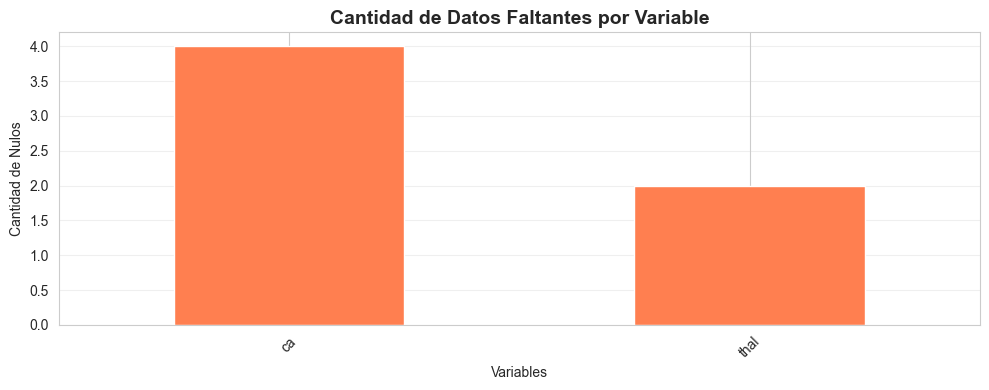

In [5]:
# ============================================================================
# 2.2 ANÁLISIS DE DATOS FALTANTES
# ============================================================================
print("\n" + "="*60)
print("🔍 ANÁLISIS DE DATOS FALTANTES")
print("="*60)

# TODO: Calcula la suma de valores nulos en cada columna de X; para esto isnull() nos buscara datos faltantes y sum() nos ayudara a contarlos
valores_nulos_X = X.isnull().sum()
print("\n📋 Valores nulos en X (features):")
print(valores_nulos_X)
print(f"\n✅ Total de valores nulos en X: {valores_nulos_X.sum()}")

# TODO: Calcula la suma de valores nulos en cada columna de y
valores_nulos_y = y.isnull().sum()
print("\n📋 Valores nulos en y (targets):")
print(valores_nulos_y)
print(f"\n✅ Total de valores nulos en y: {valores_nulos_y.sum()}")

# Calcular el porcentaje de datos faltantes
porcentaje_nulos_X = (valores_nulos_X / len(X)) * 100
print("\n📊 Porcentaje de datos faltantes por variable:")
print(porcentaje_nulos_X[porcentaje_nulos_X > 0])

# Visualizar datos faltantes
if valores_nulos_X.sum() > 0:
    plt.figure(figsize=(10, 4))
    # TODO: Filtra solo las columnas que tienen valores nulos mayor a 0
    datos_faltantes = valores_nulos_X[valores_nulos_X > 0]
    datos_faltantes.plot(kind='bar', color='coral')
    plt.title('Cantidad de Datos Faltantes por Variable', fontsize=14, fontweight='bold')
    plt.xlabel('Variables')
    plt.ylabel('Cantidad de Nulos')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


🎯 PREPARACIÓN DE VARIABLES TARGET
✅ Dimensiones del dataset completo: (303, 14)
✅ Columnas disponibles:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

🎯 CONFIGURACIÓN PARA CLASIFICACIÓN
✅ Variable target para clasificación: 'num' (binaria)
✅ Dimensiones de X_clasificacion: (303, 13)
✅ Dimensiones de y_clasificacion: (303,)

📊 Distribución de y_clasificacion:
num
0    164
1    139
Name: count, dtype: int64

📊 Primeros 5 valores de y_clasificacion: [0, 1, 1, 0, 0]

🎯 CONFIGURACIÓN PARA REGRESIÓN
✅ Variable target para regresión: 'thalach'
✅ Dimensiones de X_regresion: (303, 13)
✅ Dimensiones de y_regresion: (303,)

📊 Estadísticas de y_regresion:
count    303.000000
mean     149.607261
std       22.875003
min       71.000000
25%      133.500000
50%      153.000000
75%      166.000000
max      202.000000
Name: thalach, dtype: float64

📊 Primeros 5 valores de y_regresion: [150, 108, 129, 187, 172]

📊 VISUALIZACIÓN DE

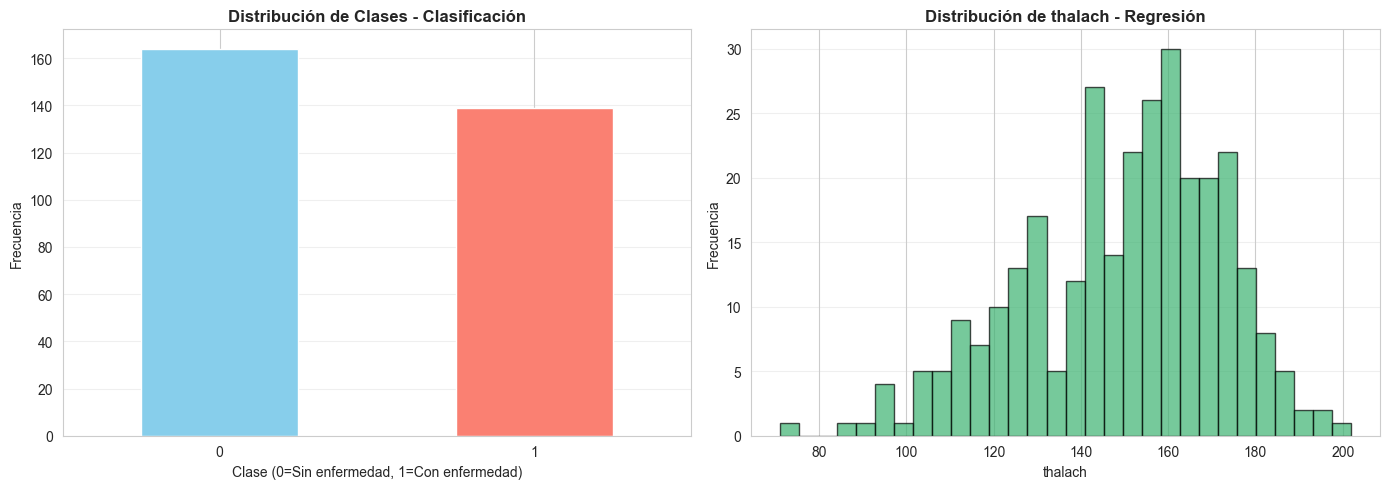


📋 RESUMEN DE LA PREPARACIÓN DE DATOS

📊 DATASET COMPLETO:
   - Total de filas: 303
   - Total de columnas: 14
   - Columnas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

🎯 PARA CLASIFICACIÓN:
   - Features (X_clasificacion): 13 variables
   - Target (y_clasificacion): 'num' (binaria)
   - Clase 0: 164 casos
   - Clase 1: 139 casos

🎯 PARA REGRESIÓN:
   - Features (X_regresion): 13 variables
   - Target (y_regresion): 'thalach'
   - Rango: [71.00, 202.00]
   - Media: 149.61
   - Desviación estándar: 22.88


✅ Datos preparados para análisis de correlación


In [6]:
# ============================================================================
# 2.3 PREPARACIÓN DE VARIABLES TARGET
# ============================================================================
print("\n" + "="*60)
print("🎯 PREPARACIÓN DE VARIABLES TARGET")
print("="*60)

# PASO 1: Concatenar X e y para tener todas las variables en un solo DataFrame
# TODO: Usa pd.concat() para unir X e y en el eje de columnas (axis=1)
datos_completos = pd.concat([X, y], axis=1)

print(f"✅ Dimensiones del dataset completo: {datos_completos.shape}")
print(f"✅ Columnas disponibles:")
print(datos_completos.columns.tolist())

# ============================================================================
# PREPARACIÓN PARA CLASIFICACIÓN
# ============================================================================
print("\n" + "="*60)
print("🎯 CONFIGURACIÓN PARA CLASIFICACIÓN")
print("="*60)

# Para CLASIFICACIÓN: usaremos 'num' como target (binario: 0=sin enfermedad, 1=con enfermedad)
# TODO: Convierte la variable 'num' a binaria (0 o 1)
y_clasificacion = (datos_completos['num'] > 0).astype(int) # Cambia a 1 si 'num' > 0, sino 0

# TODO: Selecciona todas las columnas EXCEPTO 'num' para X_clasificacion
# Puedes usar .drop() para eliminar la columna 'num'
X_clasificacion = datos_completos.drop(columns=['num'])

print(f"✅ Variable target para clasificación: 'num' (binaria)")
print(f"✅ Dimensiones de X_clasificacion: {X_clasificacion.shape}")
print(f"✅ Dimensiones de y_clasificacion: {y_clasificacion.shape}")
print(f"\n📊 Distribución de y_clasificacion:")
print(y_clasificacion.value_counts().sort_index())
print(f"\n📊 Primeros 5 valores de y_clasificacion: {y_clasificacion.head().tolist()}")

# ============================================================================
# PREPARACIÓN PARA REGRESIÓN
# ============================================================================
print("\n" + "="*60)
print("🎯 CONFIGURACIÓN PARA REGRESIÓN")
print("="*60)

# Para REGRESIÓN: Elige UNA de las siguientes variables como target:
# Opción 1: 'thalach' (ritmo cardíaco máximo alcanzado)
# Opción 2: 'trestbps' (presión arterial en reposo)

# TODO: Elige el nombre de la variable target para regresión
variable_target_regresion = 'thalach'  # Cambia a 'trestbps' si prefieres esa variable

# TODO: Selecciona la variable target del DataFrame datos_completos
y_regresion = datos_completos[variable_target_regresion]

# TODO: Selecciona todas las columnas EXCEPTO la variable target para X_regresion
X_regresion = datos_completos.drop(columns=[variable_target_regresion])

print(f"✅ Variable target para regresión: '{variable_target_regresion}'")
print(f"✅ Dimensiones de X_regresion: {X_regresion.shape}")
print(f"✅ Dimensiones de y_regresion: {y_regresion.shape}")
print(f"\n📊 Estadísticas de y_regresion:")
print(y_regresion.describe())
print(f"\n📊 Primeros 5 valores de y_regresion: {y_regresion.head().tolist()}")

# ============================================================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN DE LOS TARGETS
# ============================================================================
print("\n" + "="*60)
print("📊 VISUALIZACIÓN DE LOS TARGETS")
print("="*60)

# Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de clases para clasificación
y_clasificacion.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Distribución de Clases - Clasificación', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase (0=Sin enfermedad, 1=Con enfermedad)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticklabels(['0', '1'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Distribución del target para regresión
axes[1].hist(y_regresion.dropna(), bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Distribución de {variable_target_regresion} - Regresión', fontsize=12, fontweight='bold')
axes[1].set_xlabel(variable_target_regresion)
axes[1].set_ylabel('Frecuencia')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# RESUMEN DE LA PREPARACIÓN
# ============================================================================
print("\n" + "="*60)
print("📋 RESUMEN DE LA PREPARACIÓN DE DATOS")
print("="*60)

print(f"""
📊 DATASET COMPLETO:
   - Total de filas: {datos_completos.shape[0]}
   - Total de columnas: {datos_completos.shape[1]}
   - Columnas: {datos_completos.columns.tolist()}

🎯 PARA CLASIFICACIÓN:
   - Features (X_clasificacion): {X_clasificacion.shape[1]} variables
   - Target (y_clasificacion): 'num' (binaria)
   - Clase 0: {(y_clasificacion == 0).sum()} casos
   - Clase 1: {(y_clasificacion == 1).sum()} casos

🎯 PARA REGRESIÓN:
   - Features (X_regresion): {X_regresion.shape[1]} variables
   - Target (y_regresion): '{variable_target_regresion}'
   - Rango: [{y_regresion.min():.2f}, {y_regresion.max():.2f}]
   - Media: {y_regresion.mean():.2f}
   - Desviación estándar: {y_regresion.std():.2f}
""")

print("\n✅ Datos preparados para análisis de correlación")

## RETO 1: obtener el dataset para clasificacion multiclase para las **4 clases** de la variable num


🔗 ANÁLISIS DE CORRELACIÓN ENTRE VARIABLES


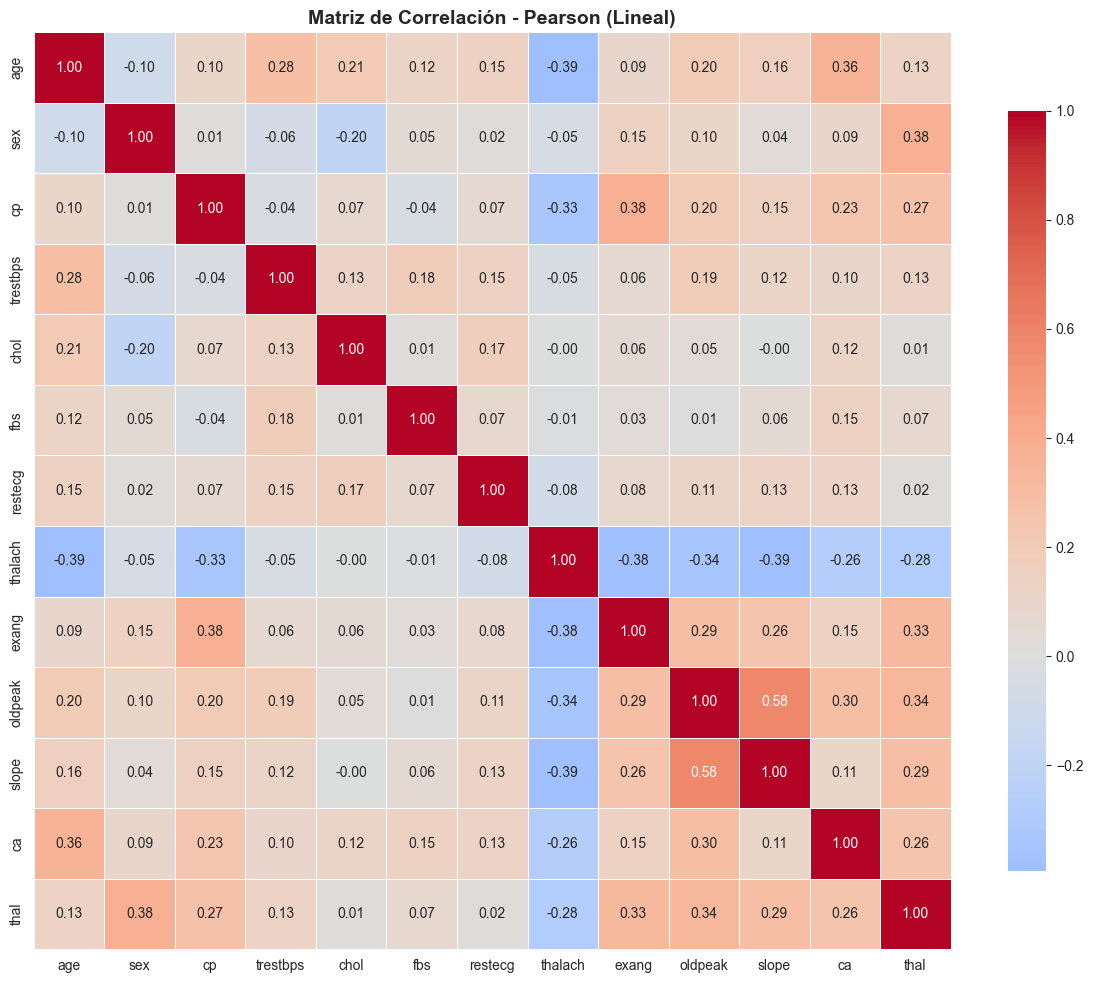

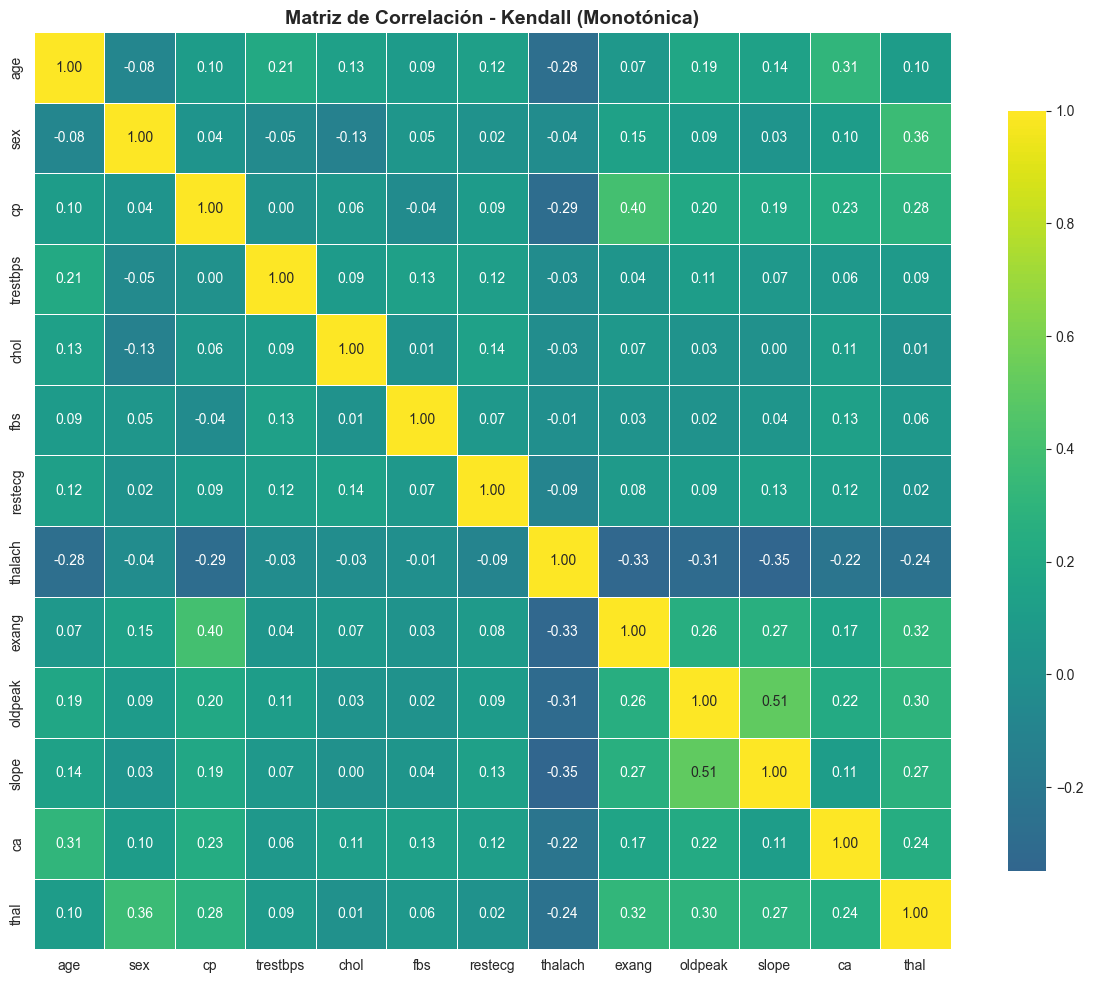

In [7]:
# ============================================================================
# 2.4 ANÁLISIS DE CORRELACIÓN
# ============================================================================
print("\n" + "="*60)
print("🔗 ANÁLISIS DE CORRELACIÓN ENTRE VARIABLES")
print("="*60)

# TODO: Calcula la matriz de correlación de Pearson
correlacion_pearson = X.corr(method='pearson')

# TODO: Calcula la matriz de correlación de Kendall
correlacion_kendall = X.corr(method='kendall')

# Visualizar matriz de correlación de Pearson
plt.figure(figsize=(12, 10))
sns.heatmap(correlacion_pearson, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Pearson (Lineal)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualizar matriz de correlación de Kendall
plt.figure(figsize=(12, 10))
sns.heatmap(correlacion_kendall, annot=True, fmt='.2f', cmap='viridis',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Kendall (Monotónica)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
# ============================================================================
# 2.5 SELECCIÓN AUTOMÁTICA DE VARIABLES (ELIMINACIÓN POR CORRELACIÓN)
# ============================================================================
print("\n" + "="*60)
print("🎯 SELECCIÓN DE VARIABLES - ELIMINACIÓN POR ALTA CORRELACIÓN")
print("="*60)

def eliminar_correlacion_alta(df, umbral=0.9):
    """
    Elimina variables con correlación mayor al umbral especificado.

    Parámetros:
    - df: DataFrame con las variables
    - umbral: Valor de correlación para eliminar (por defecto 0.9)

    Retorna:
    - DataFrame sin variables altamente correlacionadas
    - Lista de variables eliminadas
    """
    # TODO: Calcula la matriz de correlación con el método abs() para valores absolutos
    corr_matrix = df.corr(method='pearson').abs()

    # Crear conjunto para guardar variables a eliminar
    variables_eliminar = set()

    # Recorrer la matriz triangular superior
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            # TODO: Verifica si la correlación es mayor al umbral
            if corr_matrix.iloc[i, j] > umbral:
                nombre_variable = corr_matrix.columns[i]
                variables_eliminar.add(nombre_variable)
                print(f"⚠️ Correlación alta detectada: {corr_matrix.columns[j]} vs {nombre_variable} = {corr_matrix.iloc[i, j]:.3f}")

    # TODO: Elimina las columnas del DataFrame
    df_filtrado = df.drop(columns=list(variables_eliminar))

    return df_filtrado, list(variables_eliminar)

# Aplicar la función de selección
X_filtrado, vars_eliminadas = eliminar_correlacion_alta(X, umbral=0.9)

print(f"\n📊 Variables originales: {X.shape[1]}")
print(f"📊 Variables eliminadas: {len(vars_eliminadas)}")
print(f"📊 Variables restantes: {X_filtrado.shape[1]}")

if len(vars_eliminadas) > 0:
    print(f"\n🗑️ Variables eliminadas por alta correlación: {vars_eliminadas}")
else:
    print(f"\n✅ No se eliminaron variables (ninguna con correlación > 0.9)")

print(f"\n✅ Variables finales para el modelo:")
print(X_filtrado.columns.tolist())


🎯 SELECCIÓN DE VARIABLES - ELIMINACIÓN POR ALTA CORRELACIÓN

📊 Variables originales: 13
📊 Variables eliminadas: 0
📊 Variables restantes: 13

✅ No se eliminaron variables (ninguna con correlación > 0.9)

✅ Variables finales para el modelo:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [9]:
# ============================================================================
# 2.6 MANEJO DE DATOS FALTANTES
# ============================================================================
print("\n" + "="*60)
print("🔧 MANEJO DE DATOS FALTANTES")
print("="*60)

# Verificar cuántos valores nulos quedan después de filtrar variables
print("📊 Valores nulos en X_filtrado:")
print(X_filtrado.isnull().sum())
print(f"\n✅ Total de valores nulos: {X_filtrado.isnull().sum().sum()}")

# Calcular porcentaje de filas con valores nulos
filas_con_nulos = X_filtrado.isnull().any(axis=1).sum()
porcentaje_filas_nulos = (filas_con_nulos / len(X_filtrado)) * 100
print(f"\n📊 Filas con al menos un valor nulo: {filas_con_nulos} ({porcentaje_filas_nulos:.2f}%)")

print("\n" + "="*60)
print("🔀 ESTRATEGIA 1: ELIMINACIÓN DE FILAS CON VALORES NULOS")
print("="*60)

# TODO: Elimina las filas que contengan valores nulos función (dropna())
X_sin_nulos = X_filtrado.dropna()
print(f"✅ Filas antes de eliminar: {len(X_filtrado)}")
print(f"✅ Filas después de eliminar: {len(X_sin_nulos)}")
print(f"✅ Filas eliminadas: {len(X_filtrado) - len(X_sin_nulos)}")

# Alinear los targets con los índices de X_sin_nulos
y_clasificacion_sin_nulos = y_clasificacion.loc[X_sin_nulos.index]
y_regresion_sin_nulos = y_regresion.loc[X_sin_nulos.index]

print(f"\n✅ Dimensiones finales:")
print(f"   X: {X_sin_nulos.shape}")
print(f"   y_clasificacion: {y_clasificacion_sin_nulos.shape}")
print(f"   y_regresion: {y_regresion_sin_nulos.shape}")

print("\n" + "="*60)
print("🔀 ESTRATEGIA 2: IMPUTACIÓN CON MEDIANA (SimpleImputer)")
print("="*60)

from sklearn.impute import SimpleImputer

# TODO: Crea un imputador con estrategia 'median' 'median'
imputer_median = SimpleImputer(strategy='median')

# TODO: Ajusta e imputa los datos faltantes
X_imputado_median = pd.DataFrame(
    imputer_median.fit_transform(X_filtrado),
    columns=X_filtrado.columns,
    index=X_filtrado.index
)

print("📊 Valores nulos DESPUÉS de imputación con mediana:")
print(X_imputado_median.isnull().sum())
print(f"✅ Total de valores nulos: {X_imputado_median.isnull().sum().sum()}")

# Alinear targets (no necesitamos cambiar índices aquí)
y_clasificacion_median = y_clasificacion.copy()
y_regresion_median = y_regresion.copy()

print(f"\n✅ Dimensiones finales:")
print(f"   X: {X_imputado_median.shape}")
print(f"   y_clasificacion: {y_clasificacion_median.shape}")
print(f"   y_regresion: {y_regresion_median.shape}")

print("\n" + "="*60)
print("🔀 ESTRATEGIA 3: IMPUTACIÓN CON KNN (KNNImputer)")
print("="*60)

from sklearn.impute import KNNImputer

# TODO: Crea un KNNImputer con n_neighbors=5
imputer_knn = KNNImputer(n_neighbors=5)

# TODO: Ajusta e imputa los datos faltantes
X_imputado_knn = pd.DataFrame(
    imputer_knn.fit_transform(X_filtrado),
    columns=X_filtrado.columns,
    index=X_filtrado.index
)

print("📊 Valores nulos DESPUÉS de imputación con KNN:")
print(X_imputado_knn.isnull().sum())
print(f"✅ Total de valores nulos: {X_imputado_knn.isnull().sum().sum()}")

# Alinear targets
y_clasificacion_knn = y_clasificacion.copy()
y_regresion_knn = y_regresion.copy()

print(f"\n✅ Dimensiones finales:")
print(f"   X: {X_imputado_knn.shape}")
print(f"   y_clasificacion: {y_clasificacion_knn.shape}")
print(f"   y_regresion: {y_regresion_knn.shape}")


🔧 MANEJO DE DATOS FALTANTES
📊 Valores nulos en X_filtrado:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

✅ Total de valores nulos: 6

📊 Filas con al menos un valor nulo: 6 (1.98%)

🔀 ESTRATEGIA 1: ELIMINACIÓN DE FILAS CON VALORES NULOS
✅ Filas antes de eliminar: 303
✅ Filas después de eliminar: 297
✅ Filas eliminadas: 6

✅ Dimensiones finales:
   X: (297, 13)
   y_clasificacion: (297,)
   y_regresion: (297,)

🔀 ESTRATEGIA 2: IMPUTACIÓN CON MEDIANA (SimpleImputer)
📊 Valores nulos DESPUÉS de imputación con mediana:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
✅ Total de valores nulos: 0

✅ Dimensiones finales:
   X: (303, 13)
   y_clasificacion: (303,)
   y_regresion: (303,)

🔀 ESTRATEGIA 3: 

In [10]:
# ============================================================================
# 2.7 COMPARACIÓN DE ESTRATEGIAS DE IMPUTACIÓN
# ============================================================================
print("\n" + "="*60)
print("📊 COMPARACIÓN DE ESTRATEGIAS DE IMPUTACIÓN")
print("="*60)

# Seleccionar variables que tenían valores nulos
vars_con_nulos = X_filtrado.columns[X_filtrado.isnull().any()].tolist()

if len(vars_con_nulos) > 0:
    print(f"🔹 Variables que tenían valores nulos: {vars_con_nulos}\n")

    for var in vars_con_nulos:
        print(f"📌 Variable: {var}")
        print(f"   Original - Media: {X_filtrado[var].mean():.2f}, Mediana: {X_filtrado[var].median():.2f}")
        print(f"   Sin nulos - Media: {X_sin_nulos[var].mean():.2f}, Mediana: {X_sin_nulos[var].median():.2f}")
        print(f"   Imputación Mediana - Media: {X_imputado_median[var].mean():.2f}, Mediana: {X_imputado_median[var].median():.2f}")
        print(f"   Imputación KNN - Media: {X_imputado_knn[var].mean():.2f}, Mediana: {X_imputado_knn[var].median():.2f}\n")

print("\n" + "="*60)
print("🎯 SELECCIÓN DE ESTRATEGIA FINAL")
print("="*60)

print("""
📋 Resumen de estrategias disponibles:

1️⃣ ELIMINACIÓN (X_sin_nulos):
   ✅ Ventajas: Simple, no introduce sesgo
   ❌ Desventajas: Pérdida de datos ({} filas eliminadas)

2️⃣ IMPUTACIÓN MEDIANA (X_imputado_median):
   ✅ Ventajas: Conserva todas las filas, robusto ante outliers
   ❌ Desventajas: Puede reducir variabilidad

3️⃣ IMPUTACIÓN KNN (X_imputado_knn):
   ✅ Ventajas: Conserva todas las filas, usa información de vecinos
   ❌ Desventajas: Más costoso computacionalmente

💡 Recomendación: Si el porcentaje de filas con nulos es < 5%, usa ELIMINACIÓN.
   Si es > 5%, usa IMPUTACIÓN KNN para conservar información.
""".format(len(X_filtrado) - len(X_sin_nulos)))

# TODO: Selecciona la estrategia que usarás (descomentar UNA de las siguientes líneas)

# Opción 1: Eliminación
X_final = X_sin_nulos.copy()
y_clasificacion_final = y_clasificacion_sin_nulos.copy()
y_regresion_final = y_regresion_sin_nulos.copy()
estrategia_elegida = "ELIMINACIÓN"

# Opción 2: Imputación con Mediana (descomenta estas líneas si prefieres esta opción)
# X_final = X_imputado_median.copy()
# y_clasificacion_final = y_clasificacion_median.copy()
# y_regresion_final = y_regresion_median.copy()
# estrategia_elegida = "IMPUTACIÓN MEDIANA"

# Opción 3: Imputación con KNN (descomenta estas líneas si prefieres esta opción)
# X_final = X_imputado_knn.copy()
# y_clasificacion_final = y_clasificacion_knn.copy()
# y_regresion_final = y_regresion_knn.copy()
# estrategia_elegida = "IMPUTACIÓN KNN"

print(f"\n✅ Estrategia seleccionada: {estrategia_elegida}")
print(f"✅ Dimensiones finales de X_final: {X_final.shape}")
print(f"✅ Dimensiones finales de y_clasificacion_final: {y_clasificacion_final.shape}")
print(f"✅ Dimensiones finales de y_regresion_final: {y_regresion_final.shape}")


📊 COMPARACIÓN DE ESTRATEGIAS DE IMPUTACIÓN
🔹 Variables que tenían valores nulos: ['ca', 'thal']

📌 Variable: ca
   Original - Media: 0.67, Mediana: 0.00
   Sin nulos - Media: 0.68, Mediana: 0.00
   Imputación Mediana - Media: 0.66, Mediana: 0.00
   Imputación KNN - Media: 0.67, Mediana: 0.00

📌 Variable: thal
   Original - Media: 4.73, Mediana: 3.00
   Sin nulos - Media: 4.73, Mediana: 3.00
   Imputación Mediana - Media: 4.72, Mediana: 3.00
   Imputación KNN - Media: 4.73, Mediana: 3.00


🎯 SELECCIÓN DE ESTRATEGIA FINAL

📋 Resumen de estrategias disponibles:

1️⃣ ELIMINACIÓN (X_sin_nulos):
   ✅ Ventajas: Simple, no introduce sesgo
   ❌ Desventajas: Pérdida de datos (6 filas eliminadas)

2️⃣ IMPUTACIÓN MEDIANA (X_imputado_median):
   ✅ Ventajas: Conserva todas las filas, robusto ante outliers
   ❌ Desventajas: Puede reducir variabilidad

3️⃣ IMPUTACIÓN KNN (X_imputado_knn):
   ✅ Ventajas: Conserva todas las filas, usa información de vecinos
   ❌ Desventajas: Más costoso computacionalme

In [11]:
# ============================================================================
# 2.8 RESUMEN DEL ANÁLISIS EXPLORATORIO
# ============================================================================
print("\n" + "="*60)
print("🎉 RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS")
print("="*60)

print(f"""
✅ DATOS PROCESADOS:
   - Variables originales: {X.shape[1]}
   - Variables después de filtrar correlación: {X_filtrado.shape[1]}
   - Variables eliminadas por correlación alta: {len(vars_eliminadas)}
   - Filas originales: {len(X)}
   - Filas finales: {len(X_final)}
   - Estrategia de imputación: {estrategia_elegida}

✅ VARIABLES FINALES:
   {X_final.columns.tolist()}

✅ TARGETS DEFINIDOS:
   - Clasificación: 'num' (binaria: 0=sin enfermedad, 1=con enfermedad)
   - Regresión: '{y_regresion_final.name}' (variable continua)

📌 PRÓXIMO PASO: División en conjunto de entrenamiento y prueba
""")


🎉 RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS

✅ DATOS PROCESADOS:
   - Variables originales: 13
   - Variables después de filtrar correlación: 13
   - Variables eliminadas por correlación alta: 0
   - Filas originales: 303
   - Filas finales: 297
   - Estrategia de imputación: ELIMINACIÓN

✅ VARIABLES FINALES:
   ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

✅ TARGETS DEFINIDOS:
   - Clasificación: 'num' (binaria: 0=sin enfermedad, 1=con enfermedad)
   - Regresión: 'thalach' (variable continua)

📌 PRÓXIMO PASO: División en conjunto de entrenamiento y prueba



# PREPROCESAMIENTO Y DIVISIÓN DE DATOS

📦 SECCIÓN 3: PREPROCESAMIENTO Y DIVISIÓN DE DATOS

📖 Explicación General:En esta sección aprenderás a preparar los datos para el entrenamiento de modelos de Machine Learning. Los pasos clave son:

División train/test: Separar datos para entrenamiento (80%) y prueba (20%)

Análisis de balance de clases: Verificar el balance solo en el conjunto de entrenamiento

Escalamiento de datos: Normalizar las variables numéricas (Standard, Robust, MinMax)

PCA (opcional): Reducción de dimensionalidad para visualización

¿Por qué este orden?

⚠️ NUNCA escalamos antes de dividir → Causaría data leakage (filtración de información del test al train)

⚠️ El escalamiento y PCA se ajustan solo con train y se aplican a train y test

In [12]:
# ============================================================================
# 3.1 DIVISIÓN DE DATOS EN ENTRENAMIENTO Y PRUEBA
# ============================================================================
print("\n" + "="*60)
print("🔀 DIVISIÓN DE DATOS: TRAIN (80%) - TEST (20%)")
print("="*60)

# Configurar semilla para reproducibilidad
RANDOM_STATE = 42

# ============================================================================
# DIVISIÓN PARA CLASIFICACIÓN
# ============================================================================
print("\n📊 DIVISIÓN PARA CLASIFICACIÓN:")

# TODO: Divide X_final y y_clasificacion_final en train y test (80-20)
# Usa train_test_split con test_size=0.2, random_state=RANDOM_STATE, stratify=y_clasificacion_final
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_final,
    y_clasificacion_final,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clasificacion_final
)

print(f"✅ X_train_clf: {X_train_clf.shape}")
print(f"✅ X_test_clf: {X_test_clf.shape}")
print(f"✅ y_train_clf: {y_train_clf.shape}")
print(f"✅ y_test_clf: {y_test_clf.shape}")

# ============================================================================
# DIVISIÓN PARA REGRESIÓN
# ============================================================================
print("\n📊 DIVISIÓN PARA REGRESIÓN:")

# TODO: Divide X_final y y_regresion_final en train y test (80-20)
# Usa train_test_split con test_size=0.2, random_state=RANDOM_STATE
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_final,
    y_regresion_final,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"✅ X_train_reg: {X_train_reg.shape}")
print(f"✅ X_test_reg: {X_test_reg.shape}")
print(f"✅ y_train_reg: {y_train_reg.shape}")
print(f"✅ y_test_reg: {y_test_reg.shape}")


🔀 DIVISIÓN DE DATOS: TRAIN (80%) - TEST (20%)

📊 DIVISIÓN PARA CLASIFICACIÓN:
✅ X_train_clf: (237, 13)
✅ X_test_clf: (60, 13)
✅ y_train_clf: (237,)
✅ y_test_clf: (60,)

📊 DIVISIÓN PARA REGRESIÓN:
✅ X_train_reg: (237, 13)
✅ X_test_reg: (60, 13)
✅ y_train_reg: (237,)
✅ y_test_reg: (60,)



⚖️ ANÁLISIS DE BALANCE DE CLASES (Solo en Train)

📊 Distribución de clases en TRAIN:
num
0    128
1    109
Name: count, dtype: int64

📊 Porcentaje de cada clase en TRAIN:
   Clase 0: 54.01%
   Clase 1: 45.99%

📊 Distribución de clases en TEST:
num
0    32
1    28
Name: count, dtype: int64


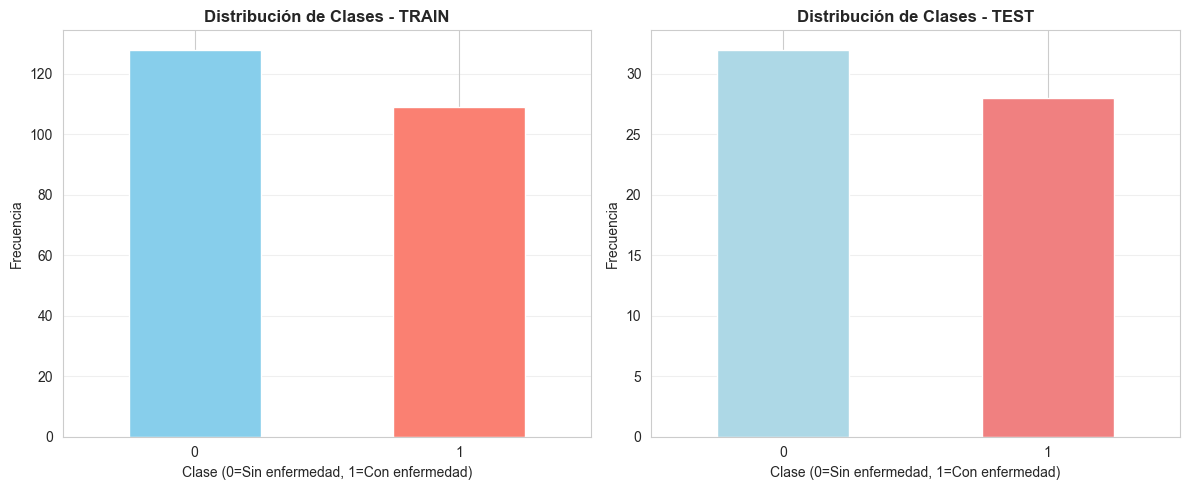


💡 RECOMENDACIÓN DE MÉTRICA PARA CLASIFICACIÓN
✅ Las clases están BALANCEADAS (ratio: 0.85)
   📌 Métrica recomendada: Accuracy
   📌 Otras métricas útiles: Precision, Recall, F1-Score, ROC-AUC


In [13]:
# ============================================================================
# 3.2 ANÁLISIS DE BALANCE DE CLASES EN TRAIN
# ============================================================================
print("\n" + "="*60)
print("⚖️ ANÁLISIS DE BALANCE DE CLASES (Solo en Train)")
print("="*60)

# TODO: Cuenta cuántos casos hay de cada clase en y_train_clf
conteo_train = y_train_clf.value_counts()
print("\n📊 Distribución de clases en TRAIN:")
print(conteo_train)

# Calcular porcentajes
porcentaje_train = (conteo_train / len(y_train_clf)) * 100
print("\n📊 Porcentaje de cada clase en TRAIN:")
for clase, porcentaje in porcentaje_train.items():
    print(f"   Clase {clase}: {porcentaje:.2f}%")

# Verificar balance en TEST también (solo para información)
conteo_test = y_test_clf.value_counts()
print("\n📊 Distribución de clases en TEST:")
print(conteo_test)

# Visualizar distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Train
conteo_train.sort_index().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Distribución de Clases - TRAIN', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase (0=Sin enfermedad, 1=Con enfermedad)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticklabels(['0', '1'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Test
conteo_test.sort_index().plot(kind='bar', ax=axes[1], color=['lightblue', 'lightcoral'])
axes[1].set_title('Distribución de Clases - TEST', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Clase (0=Sin enfermedad, 1=Con enfermedad)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xticklabels(['0', '1'], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Determinar métrica recomendada
ratio = min(porcentaje_train) / max(porcentaje_train)
print("\n" + "="*60)
print("💡 RECOMENDACIÓN DE MÉTRICA PARA CLASIFICACIÓN")
print("="*60)
if ratio > 0.7:
    print(f"✅ Las clases están BALANCEADAS (ratio: {ratio:.2f})")
    print("   📌 Métrica recomendada: Accuracy")
    print("   📌 Otras métricas útiles: Precision, Recall, F1-Score, ROC-AUC")
else:
    print(f"⚠️ Las clases están DESBALANCEADAS (ratio: {ratio:.2f})")
    print("   📌 Métrica recomendada: F1-Score o ROC-AUC")
    print("   📌 Evitar: Accuracy (puede ser engañosa)")


📏 ESCALAMIENTO DE DATOS

Probaremos 4 configuraciones de escalamiento:
1️⃣ SIN ESCALADO: Datos originales
2️⃣ STANDARD SCALER: Media=0, Desviación=1 (asume distribución normal)
3️⃣ ROBUST SCALER: Usa mediana y rango intercuartílico (robusto a outliers)
4️⃣ MINMAX SCALER: Escala al rango [0, 1]

⚠️ IMPORTANTE: El escalador se ajusta SOLO con train y se aplica a train y test


📌 Configuración 1: SIN ESCALADO
------------------------------------------------------------
✅ Datos sin escalar guardados

📌 Configuración 2: STANDARD SCALER
------------------------------------------------------------
✅ StandardScaler aplicado
   Media de X_train_clf_standard: -0.000000
   Desv.Est. de X_train_clf_standard: 1.000000

📌 Configuración 3: ROBUST SCALER
------------------------------------------------------------
✅ RobustScaler aplicado
   Mediana de X_train_clf_robust: 0.000000

📌 Configuración 4: MINMAX SCALER
------------------------------------------------------------
✅ MinMaxScaler aplicado
   

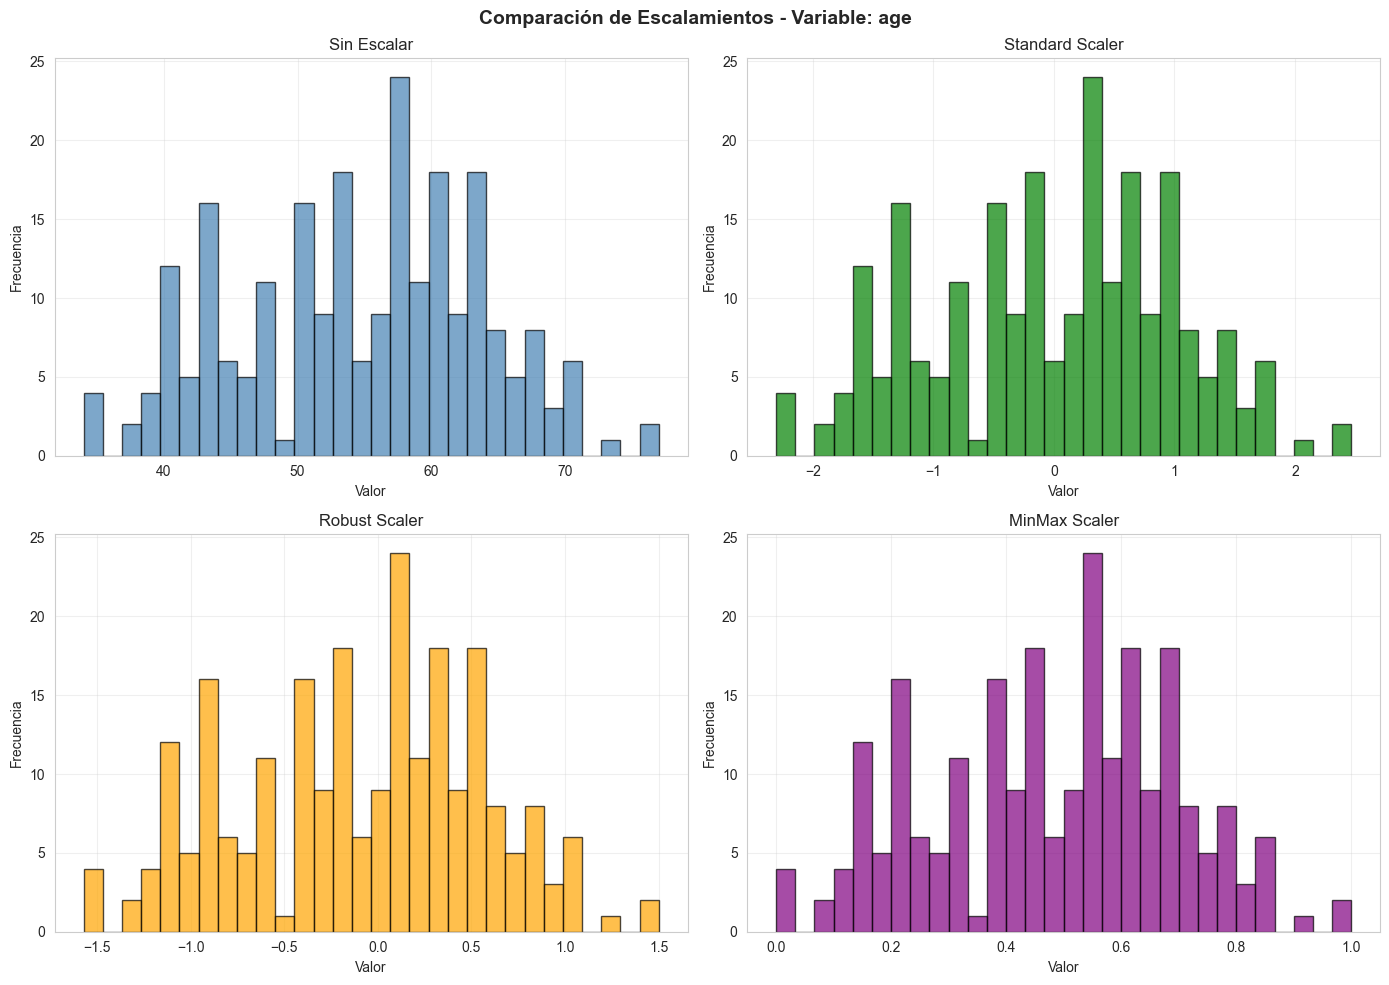

In [16]:
# ============================================================================
# 3.3 ESCALAMIENTO DE DATOS
# ============================================================================
print("\n" + "="*60)
print("📏 ESCALAMIENTO DE DATOS")
print("="*60)

print("""
Probaremos 4 configuraciones de escalamiento:
1️⃣ SIN ESCALADO: Datos originales
2️⃣ STANDARD SCALER: Media=0, Desviación=1 (asume distribución normal)
3️⃣ ROBUST SCALER: Usa mediana y rango intercuartílico (robusto a outliers)
4️⃣ MINMAX SCALER: Escala al rango [0, 1]

⚠️ IMPORTANTE: El escalador se ajusta SOLO con train y se aplica a train y test
""")

# ============================================================================
# CONFIGURACIÓN 1: SIN ESCALADO
# ============================================================================
print("\n📌 Configuración 1: SIN ESCALADO")
print("-" * 60)

# Para clasificación
X_train_clf_sin_escala = X_train_clf.copy()
X_test_clf_sin_escala = X_test_clf.copy()

# Para regresión
X_train_reg_sin_escala = X_train_reg.copy()
X_test_reg_sin_escala = X_test_reg.copy()

print("✅ Datos sin escalar guardados")

# ============================================================================
# CONFIGURACIÓN 2: STANDARD SCALER
# ============================================================================
print("\n📌 Configuración 2: STANDARD SCALER")
print("-" * 60)

# TODO: Crea un StandardScaler
scaler_standard = StandardScaler()

# Para CLASIFICACIÓN
# TODO: Ajusta el scaler con X_train_clf y transforma train y test
X_train_clf_standard = scaler_standard.fit_transform(X_train_clf)
X_test_clf_standard = scaler_standard.transform(X_test_clf)

# Para REGRESIÓN
# TODO: Crea un nuevo StandardScaler para regresión
scaler_standard_reg = StandardScaler()
X_train_reg_standard = scaler_standard_reg.fit_transform(X_train_reg)
X_test_reg_standard = scaler_standard_reg.transform(X_test_reg)

print("✅ StandardScaler aplicado")
print(f"   Media de X_train_clf_standard: {X_train_clf_standard.mean():.6f}")
print(f"   Desv.Est. de X_train_clf_standard: {X_train_clf_standard.std():.6f}")

# ============================================================================
# CONFIGURACIÓN 3: ROBUST SCALER
# ============================================================================
print("\n📌 Configuración 3: ROBUST SCALER")
print("-" * 60)

# TODO: Crea un RobustScaler
scaler_robust = RobustScaler()

# Para CLASIFICACIÓN
X_train_clf_robust = scaler_robust.fit_transform(X_train_clf)
X_test_clf_robust = scaler_robust.transform(X_test_clf)

# Para REGRESIÓN
scaler_robust_reg = RobustScaler()
X_train_reg_robust = scaler_robust_reg.fit_transform(X_train_reg)
X_test_reg_robust = scaler_robust_reg.transform(X_test_reg)

print("✅ RobustScaler aplicado")
print(f"   Mediana de X_train_clf_robust: {np.median(X_train_clf_robust):.6f}")

# ============================================================================
# CONFIGURACIÓN 4: MINMAX SCALER
# ============================================================================
print("\n📌 Configuración 4: MINMAX SCALER")
print("-" * 60)

# TODO: Crea un MinMaxScaler
scaler_minmax = MinMaxScaler()

# Para CLASIFICACIÓN
X_train_clf_minmax = scaler_minmax.fit_transform(X_train_clf)
X_test_clf_minmax = scaler_minmax.transform(X_test_clf)

# Para REGRESIÓN
scaler_minmax_reg = MinMaxScaler()
X_train_reg_minmax = scaler_minmax_reg.fit_transform(X_train_reg)
X_test_reg_minmax = scaler_minmax_reg.transform(X_test_reg)

print("✅ MinMaxScaler aplicado")
print(f"   Mínimo de X_train_clf_minmax: {X_train_clf_minmax.min():.6f}")
print(f"   Máximo de X_train_clf_minmax: {X_train_clf_minmax.max():.6f}")

# ============================================================================
# COMPARACIÓN VISUAL DE ESCALAMIENTOS
# ============================================================================
print("\n📊 Visualización de efectos del escalamiento")

# Seleccionar una variable para comparar (ejemplo: primera columna)
variable_ejemplo = X_train_clf.columns[0]
idx_variable = 0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Comparación de Escalamientos - Variable: {variable_ejemplo}',
             fontsize=14, fontweight='bold')

# Sin escalar
axes[0, 0].hist(X_train_clf.iloc[:, idx_variable], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Sin Escalar')
axes[0, 0].set_xlabel('Valor')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(alpha=0.3)

# Standard Scaler
axes[0, 1].hist(X_train_clf_standard[:, idx_variable], bins=30, color='green', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Standard Scaler')
axes[0, 1].set_xlabel('Valor')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(alpha=0.3)

# Robust Scaler
axes[1, 0].hist(X_train_clf_robust[:, idx_variable], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Robust Scaler')
axes[1, 0].set_xlabel('Valor')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(alpha=0.3)

# MinMax Scaler
axes[1, 1].hist(X_train_clf_minmax[:, idx_variable], bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('MinMax Scaler')
axes[1, 1].set_xlabel('Valor')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



🔬 PCA - ANÁLISIS DE COMPONENTES PRINCIPALES

PCA (Principal Component Analysis) reduce la dimensionalidad manteniendo
la máxima varianza posible. Lo usaremos principalmente para:
- Visualización de fronteras de decisión en 2D
- Comparar rendimiento con/sin reducción dimensional

⚠️ IMPORTANTE: PCA se aplica SOLO sobre datos escalados


📌 Aplicando PCA con 2 componentes para visualización

✅ PCA para Clasificación:
   Dimensiones originales: 13
   Dimensiones después de PCA: 2
   Varianza explicada por componente: [0.23236266 0.13007763]
   Varianza total explicada: 36.24%

✅ PCA para Regresión:
   Dimensiones originales: 13
   Dimensiones después de PCA: 2
   Varianza explicada por componente: [0.23072531 0.12510136]
   Varianza total explicada: 35.58%

📊 Visualización de datos en espacio PCA


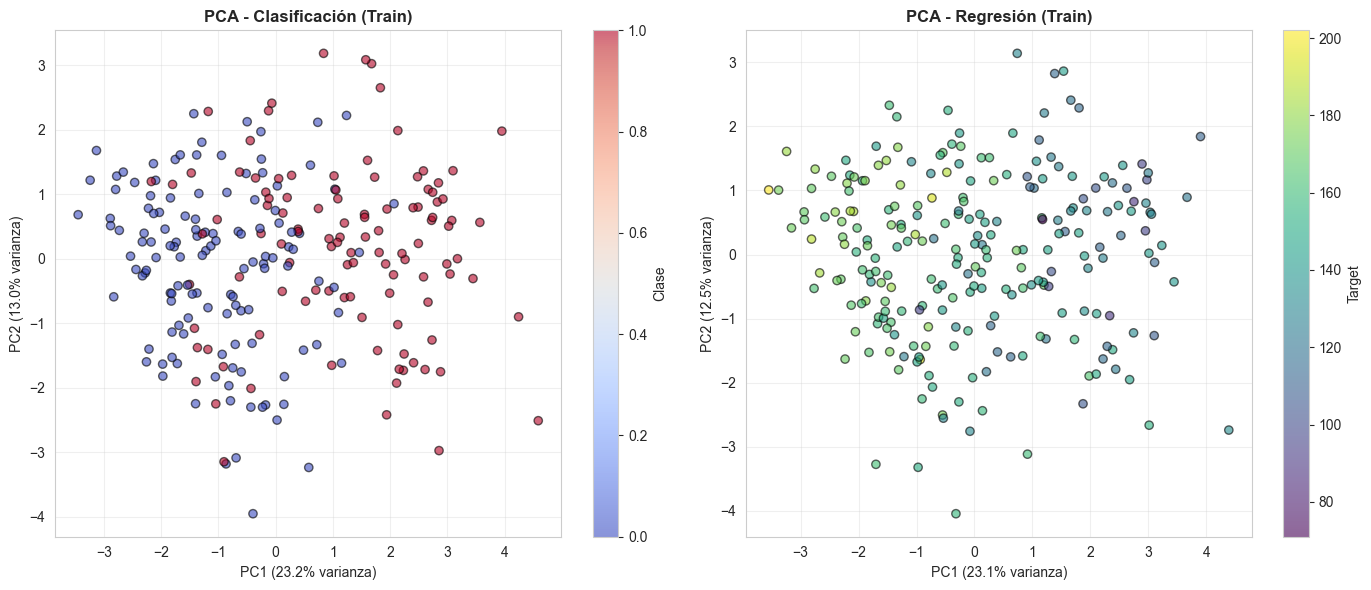

In [17]:
# ============================================================================
# 3.4 PCA - REDUCCIÓN DE DIMENSIONALIDAD (OPCIONAL)
# ============================================================================
print("\n" + "="*60)
print("🔬 PCA - ANÁLISIS DE COMPONENTES PRINCIPALES")
print("="*60)

print("""
PCA (Principal Component Analysis) reduce la dimensionalidad manteniendo
la máxima varianza posible. Lo usaremos principalmente para:
- Visualización de fronteras de decisión en 2D
- Comparar rendimiento con/sin reducción dimensional

⚠️ IMPORTANTE: PCA se aplica SOLO sobre datos escalados
""")

# Usar StandardScaler para PCA (recomendado)
print("\n📌 Aplicando PCA con 2 componentes para visualización")

# ============================================================================
# PCA PARA CLASIFICACIÓN
# ============================================================================
# TODO: Crea un PCA con n_components=2
pca_clf = PCA(n_components=2)

# TODO: Ajusta el PCA con X_train_clf_standard y transforma train y test
X_train_clf_pca = pca_clf.fit_transform(X_train_clf_standard)
X_test_clf_pca = pca_clf.transform(X_test_clf_standard)

print("\n✅ PCA para Clasificación:")
print(f"   Dimensiones originales: {X_train_clf_standard.shape[1]}")
print(f"   Dimensiones después de PCA: {X_train_clf_pca.shape[1]}")
print(f"   Varianza explicada por componente: {pca_clf.explained_variance_ratio_}")
print(f"   Varianza total explicada: {pca_clf.explained_variance_ratio_.sum():.2%}")

# ============================================================================
# PCA PARA REGRESIÓN
# ============================================================================
pca_reg = PCA(n_components=2)
X_train_reg_pca = pca_reg.fit_transform(X_train_reg_standard)
X_test_reg_pca = pca_reg.transform(X_test_reg_standard)

print("\n✅ PCA para Regresión:")
print(f"   Dimensiones originales: {X_train_reg_standard.shape[1]}")
print(f"   Dimensiones después de PCA: {X_train_reg_pca.shape[1]}")
print(f"   Varianza explicada por componente: {pca_reg.explained_variance_ratio_}")
print(f"   Varianza total explicada: {pca_reg.explained_variance_ratio_.sum():.2%}")

# ============================================================================
# VISUALIZACIÓN DE DATOS EN ESPACIO PCA
# ============================================================================
print("\n📊 Visualización de datos en espacio PCA")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Clasificación
scatter_clf = axes[0].scatter(X_train_clf_pca[:, 0], X_train_clf_pca[:, 1],
                               c=y_train_clf, cmap='coolwarm', alpha=0.6, edgecolors='k')
axes[0].set_title('PCA - Clasificación (Train)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_clf.explained_variance_ratio_[0]:.1%} varianza)')
axes[0].set_ylabel(f'PC2 ({pca_clf.explained_variance_ratio_[1]:.1%} varianza)')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter_clf, ax=axes[0], label='Clase')

# Regresión
scatter_reg = axes[1].scatter(X_train_reg_pca[:, 0], X_train_reg_pca[:, 1],
                               c=y_train_reg, cmap='viridis', alpha=0.6, edgecolors='k')
axes[1].set_title('PCA - Regresión (Train)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_reg.explained_variance_ratio_[0]:.1%} varianza)')
axes[1].set_ylabel(f'PC2 ({pca_reg.explained_variance_ratio_[1]:.1%} varianza)')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter_reg, ax=axes[1], label='Target')

plt.tight_layout()
plt.show()


In [18]:
# ============================================================================
# 3.5 RESUMEN DE PREPROCESAMIENTO
# ============================================================================
print("\n" + "="*60)
print("🎉 RESUMEN DEL PREPROCESAMIENTO")
print("="*60)

print(f"""
✅ DIVISIÓN DE DATOS:
   - Train: 80% ({len(X_train_clf)} muestras)
   - Test: 20% ({len(X_test_clf)} muestras)

✅ ESCALAMIENTOS DISPONIBLES:
   1. Sin escalar
   2. Standard Scaler (media=0, std=1)
   3. Robust Scaler (robusto a outliers)
   4. MinMax Scaler (rango [0,1])

✅ PCA APLICADO:
   - Reducción a 2 componentes
   - Varianza explicada (Clasificación): {pca_clf.explained_variance_ratio_.sum():.2%}
   - Varianza explicada (Regresión): {pca_reg.explained_variance_ratio_.sum():.2%}

✅ DATOS LISTOS PARA MODELADO:
   - Clasificación: 4 configuraciones de escalamiento (con y sin PCA)
   - Regresión: 4 configuraciones de escalamiento (con y sin PCA)

📌 PRÓXIMO PASO: Entrenar y optimizar modelos con GridSearchCV
""")


🎉 RESUMEN DEL PREPROCESAMIENTO

✅ DIVISIÓN DE DATOS:
   - Train: 80% (237 muestras)
   - Test: 20% (60 muestras)

✅ ESCALAMIENTOS DISPONIBLES:
   1. Sin escalar
   2. Standard Scaler (media=0, std=1)
   3. Robust Scaler (robusto a outliers)
   4. MinMax Scaler (rango [0,1])

✅ PCA APLICADO:
   - Reducción a 2 componentes
   - Varianza explicada (Clasificación): 36.24%
   - Varianza explicada (Regresión): 35.58%

✅ DATOS LISTOS PARA MODELADO:
   - Clasificación: 4 configuraciones de escalamiento (con y sin PCA)
   - Regresión: 4 configuraciones de escalamiento (con y sin PCA)

📌 PRÓXIMO PASO: Entrenar y optimizar modelos con GridSearchCV



# 🤖 SECCIÓN 4: ENTRENAMIENTO Y OPTIMIZACIÓN DE MODELOS CON GRIDSEARCHCV

📖 Explicación General:

En esta sección aprenderás a:


Definir hiperparámetros: Crear rangos de valores para optimizar cada modelo

GridSearchCV: Búsqueda exhaustiva de la mejor combinación de hiperparámetros

Cross-Validation: Validación cruzada con 5 folds para evaluar robustez

Optimización por métrica: Seleccionar la mejor configuración según la métrica de interés

Modelos a entrenar:

Clasificación: KNN, Regresión Logística
Regresión: KNN, Regresión Lineal

Configuraciones a probar:

4 tipos de escalamiento (sin escalar, standard, robust, minmax)
Con y sin PCA (8 configuraciones por modelo)

In [21]:
# ============================================================================
# 4.1 DEFINICIÓN DE HIPERPARÁMETROS PARA GRIDSEARCHCV
# ============================================================================
print("\n" + "="*60)
print("🎯 DEFINICIÓN DE HIPERPARÁMETROS PARA OPTIMIZACIÓN")
print("="*60)

print("""
GridSearchCV probará TODAS las combinaciones posibles de hiperparámetros
y seleccionará la mejor según la métrica elegida.

⚠️ IMPORTANTE: Ajusta los rangos según tu tiempo disponible.
   Más valores = Mejor búsqueda, pero más tiempo de cómputo.
""")

# ============================================================================
# HIPERPARÁMETROS PARA KNN CLASIFICACIÓN
# ============================================================================
print("\n📌 KNN - Clasificación")
print("-" * 60)

# TODO: Define el rango de valores para cada hiperparámetro
param_grid_knn_clf = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Ejemplo: [3, 5, 7, 9, 11]
    'weights': ['uniform', 'distance'],  # Ejemplo: ['uniform', 'distance']
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Ejemplo: ['euclidean', 'manhattan', 'minkowski']
}

print("Hiperparámetros a optimizar:")
for param, valores in param_grid_knn_clf.items():
    print(f"   {param}: {valores}")

total_combinaciones_knn_clf = (len(param_grid_knn_clf['n_neighbors']) *
                                len(param_grid_knn_clf['weights']) *
                                len(param_grid_knn_clf['metric']))
print(f"\n💡 Total de combinaciones a probar: {total_combinaciones_knn_clf}")
print(f"   Con 5-fold CV: {total_combinaciones_knn_clf * 5} entrenamientos por configuración")

# ============================================================================
# HIPERPARÁMETROS PARA REGRESIÓN LOGÍSTICA
# ============================================================================
print("\n📌 Regresión Logística - Clasificación")
print("-" * 60)

# TODO: Define el rango de valores para cada hiperparámetro
param_grid_logistic = {
    'C': [0.01, 0.1, 1, 10],  # Ejemplo: [0.01, 0.1, 1, 10]
    'penalty': ['l1', 'l2'],  # Ejemplo: ['l1', 'l2']
    'solver': ['liblinear', 'saga'],  # Ejemplo: ['liblinear', 'saga']
    'max_iter': [1000]  # Ejemplo: [1000]
}

print("Hiperparámetros a optimizar:")
for param, valores in param_grid_logistic.items():
    print(f"   {param}: {valores}")

total_combinaciones_logistic = (len(param_grid_logistic['C']) *
                                 len(param_grid_logistic['penalty']) *
                                 len(param_grid_logistic['solver']) *
                                 len(param_grid_logistic['max_iter']))
print(f"\n💡 Total de combinaciones a probar: {total_combinaciones_logistic}")
print(f"   Con 5-fold CV: {total_combinaciones_logistic * 5} entrenamientos por configuración")

# ============================================================================
# HIPERPARÁMETROS PARA KNN REGRESIÓN
# ============================================================================
print("\n📌 KNN - Regresión")
print("-" * 60)

# TODO: Define el rango de valores para cada hiperparámetro
param_grid_knn_reg = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Ejemplo: [3, 5, 7, 9, 11]
    'weights': ['uniform', 'distance'],  # Ejemplo: ['uniform', 'distance']
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Ejemplo: ['euclidean', 'manhattan', 'minkowski']
}

print("Hiperparámetros a optimizar:")
for param, valores in param_grid_knn_reg.items():
    print(f"   {param}: {valores}")

total_combinaciones_knn_reg = (len(param_grid_knn_reg['n_neighbors']) *
                               len(param_grid_knn_reg['weights']) *
                               len(param_grid_knn_reg['metric']))
print(f"\n💡 Total de combinaciones a probar: {total_combinaciones_knn_reg}")
print(f"   Con 5-fold CV: {total_combinaciones_knn_reg * 5} entrenamientos por configuración")

# ============================================================================
# HIPERPARÁMETROS PARA REGRESIÓN LINEAL
# ============================================================================
print("\n📌 Regresión Lineal")
print("-" * 60)

# TODO: Define el rango de valores para cada hiperparámetro
# Para Regresión Lineal simple (sin regularización), no hay hiperparámetros
# Pero podemos usar Ridge o Lasso para agregar regularización
from sklearn.linear_model import Ridge

param_grid_linear_reg = {
    'alpha': [0.01, 0.1, 1, 10, 100],  # Ejemplo: [0.01, 0.1, 1, 10, 100]
    'fit_intercept': [True, False],  # Ejemplo: [True, False]
    'solver': ['auto']  # Ejemplo: ['auto'] o ['cholesky', 'lsqr', 'saga']
}

print("Hiperparámetros a optimizar (Ridge Regression):")
for param, valores in param_grid_linear_reg.items():
    print(f"   {param}: {valores}")

total_combinaciones_linear = (len(param_grid_linear_reg['alpha']) *
                              len(param_grid_linear_reg['fit_intercept']) *
                              len(param_grid_linear_reg['solver']))
print(f"\n💡 Total de combinaciones a probar: {total_combinaciones_linear}")
print(f"   Con 5-fold CV: {total_combinaciones_linear * 5} entrenamientos por configuración")


🎯 DEFINICIÓN DE HIPERPARÁMETROS PARA OPTIMIZACIÓN

GridSearchCV probará TODAS las combinaciones posibles de hiperparámetros
y seleccionará la mejor según la métrica elegida.

⚠️ IMPORTANTE: Ajusta los rangos según tu tiempo disponible.
   Más valores = Mejor búsqueda, pero más tiempo de cómputo.


📌 KNN - Clasificación
------------------------------------------------------------
Hiperparámetros a optimizar:
   n_neighbors: [3, 5, 7, 9, 11]
   weights: ['uniform', 'distance']
   metric: ['euclidean', 'manhattan', 'minkowski']

💡 Total de combinaciones a probar: 30
   Con 5-fold CV: 150 entrenamientos por configuración

📌 Regresión Logística - Clasificación
------------------------------------------------------------
Hiperparámetros a optimizar:
   C: [0.01, 0.1, 1, 10]
   penalty: ['l1', 'l2']
   solver: ['liblinear', 'saga']
   max_iter: [1000]

💡 Total de combinaciones a probar: 16
   Con 5-fold CV: 80 entrenamientos por configuración

📌 KNN - Regresión
------------------------------

In [22]:
# ============================================================================
# 4.2 FUNCIÓN AUXILIAR PARA ENTRENAR CON GRIDSEARCHCV
# ============================================================================
print("\n" + "="*60)
print("🔧 CONFIGURACIÓN DE GRIDSEARCHCV")
print("="*60)

def entrenar_gridsearch(modelo, param_grid, X_train, y_train, scoring, cv=5, nombre_modelo="Modelo"):  #estimator=modelo,   param_grid=param_grid,  scoring=scoring,  cv=cv,
    """
    Entrena un modelo usando GridSearchCV con validación cruzada.

    Parámetros:
    - modelo: Instancia del modelo a entrenar
    - param_grid: Diccionario con hiperparámetros a probar
    - X_train: Datos de entrenamiento
    - y_train: Target de entrenamiento
    - scoring: Métrica a optimizar
    - cv: Número de folds para cross-validation
    - nombre_modelo: Nombre del modelo para mensajes

    Retorna:
    - grid_search: Objeto GridSearchCV entrenado
    """
    print(f"\n🚀 Entrenando {nombre_modelo}...")
    print(f"   Métrica de optimización: {scoring}")
    print(f"   Cross-Validation: {cv}-fold")

    # TODO: Crea el GridSearchCV con el modelo, param_grid, scoring y cv
    grid_search = GridSearchCV(
        estimator=modelo,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,  # Usar todos los núcleos disponibles
        verbose=1
    )

    # TODO: Entrena el GridSearchCV
    grid_search.fit(X_train, y_train) # poner en modo entrenamiento

    print(f"\n✅ {nombre_modelo} entrenado exitosamente")
    print(f"   Mejores hiperparámetros: {grid_search.best_params_}")
    print(f"   Mejor score (CV): {grid_search.best_score_:.4f}")

    return grid_search



🔧 CONFIGURACIÓN DE GRIDSEARCHCV


In [23]:
# ============================================================================
# 4.3 ENTRENAMIENTO DE MODELOS - CLASIFICACIÓN
# ============================================================================
print("\n" + "="*60)
print("🎯 ENTRENAMIENTO DE MODELOS - CLASIFICACIÓN")
print("="*60)

# Decidir métrica de optimización según balance de clases
# TODO: Elige la métrica apropiada según tu análisis de balance
# Opciones: 'accuracy', 'f1', 'roc_auc', 'precision', 'recall'
metrica_clasificacion = 'f1'  # Ejemplo: 'f1' si está desbalanceado, 'accuracy' si está balanceado

print(f"\n📊 Métrica seleccionada para clasificación: {metrica_clasificacion}")

# Diccionario para almacenar resultados
resultados_clf = {}

# ============================================================================
# CONFIGURACIÓN DE ESCALAMIENTOS PARA CLASIFICACIÓN
# ============================================================================
configuraciones_clf = {
    'Sin Escalar': X_train_clf_sin_escala,
    'Standard': X_train_clf_standard,
    'Robust': X_train_clf_robust,
    'MinMax': X_train_clf_minmax
}

# ============================================================================
# ENTRENAR KNN - CLASIFICACIÓN
# ============================================================================
print("\n" + "="*60)
print("🔹 KNN - CLASIFICACIÓN")
print("="*60)

resultados_clf['KNN'] = {}

for nombre_config, X_train_escalado in configuraciones_clf.items():
    print(f"\n📌 Configuración: {nombre_config}")

    # TODO: Crea una instancia de KNeighborsClassifier
    knn_clf = KNeighborsClassifier()

    # Entrenar con GridSearchCV
    grid_knn_clf = entrenar_gridsearch(
        modelo=knn_clf,
        param_grid=param_grid_knn_clf,
        X_train=X_train_escalado,
        y_train=y_train_clf,
        scoring=metrica_clasificacion,
        cv=5,
        nombre_modelo=f"KNN-{nombre_config}"
    )

    # Guardar resultados
    resultados_clf['KNN'][nombre_config] = {
        'grid_search': grid_knn_clf,
        'best_params': grid_knn_clf.best_params_,
        'best_score': grid_knn_clf.best_score_
    }

# ============================================================================
# ENTRENAR REGRESIÓN LOGÍSTICA - CLASIFICACIÓN
# ============================================================================
print("\n" + "="*60)
print("🔹 REGRESIÓN LOGÍSTICA - CLASIFICACIÓN")
print("="*60)

resultados_clf['Logistic'] = {}

for nombre_config, X_train_escalado in configuraciones_clf.items():
    print(f"\n📌 Configuración: {nombre_config}")

    # TODO: Crea una instancia de LogisticRegression
    logistic_clf = LogisticRegression()

    # Entrenar con GridSearchCV
    grid_logistic = entrenar_gridsearch(
        modelo=logistic_clf,
        param_grid=param_grid_logistic,
        X_train=X_train_escalado,
        y_train=y_train_clf,
        scoring=metrica_clasificacion,
        cv=5,
        nombre_modelo=f"LogisticRegression-{nombre_config}"
    )

    # Guardar resultados
    resultados_clf['Logistic'][nombre_config] = {
        'grid_search': grid_logistic,
        'best_params': grid_logistic.best_params_,
        'best_score': grid_logistic.best_score_
    }


🎯 ENTRENAMIENTO DE MODELOS - CLASIFICACIÓN

📊 Métrica seleccionada para clasificación: f1

🔹 KNN - CLASIFICACIÓN

📌 Configuración: Sin Escalar

🚀 Entrenando KNN-Sin Escalar...
   Métrica de optimización: f1
   Cross-Validation: 5-fold
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ KNN-Sin Escalar entrenado exitosamente
   Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
   Mejor score (CV): 0.6556

📌 Configuración: Standard

🚀 Entrenando KNN-Standard...
   Métrica de optimización: f1
   Cross-Validation: 5-fold
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ KNN-Standard entrenado exitosamente
   Mejores hiperparámetros: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
   Mejor score (CV): 0.8038

📌 Configuración: Robust

🚀 Entrenando KNN-Robust...
   Métrica de optimización: f1
   Cross-Validation: 5-fold
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ KNN-Robust entrenado exi

In [24]:
# ============================================================================
# 4.4 ENTRENAMIENTO DE MODELOS - REGRESIÓN
# ============================================================================
print("\n" + "="*60)
print("🎯 ENTRENAMIENTO DE MODELOS - REGRESIÓN")
print("="*60)

# TODO: Métrica para regresión (usa 'neg_root_mean_squared_error' para RMSE)
metrica_regresion = 'neg_root_mean_squared_error'  # Ejemplo: 'neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error'

print(f"\n📊 Métrica seleccionada para regresión: {metrica_regresion}")
print("   ⚠️ Nota: sklearn usa valores negativos para métricas de error (menor es mejor)")

# Diccionario para almacenar resultados
resultados_reg = {}

# ============================================================================
# CONFIGURACIÓN DE ESCALAMIENTOS PARA REGRESIÓN
# ============================================================================
configuraciones_reg = {
    'Sin Escalar': X_train_reg_sin_escala,
    'Standard': X_train_reg_standard,
    'Robust': X_train_reg_robust,
    'MinMax': X_train_reg_minmax
}

# ============================================================================
# ENTRENAR KNN - REGRESIÓN
# ============================================================================
print("\n" + "="*60)
print("🔹 KNN - REGRESIÓN")
print("="*60)

resultados_reg['KNN'] = {}

for nombre_config, X_train_escalado in configuraciones_reg.items():
    print(f"\n📌 Configuración: {nombre_config}")

    # TODO: Crea una instancia de KNeighborsRegressor
    knn_reg = KNeighborsRegressor()

    # Entrenar con GridSearchCV
    grid_knn_reg = entrenar_gridsearch(
        modelo=knn_reg,
        param_grid=param_grid_knn_reg,
        X_train=X_train_escalado,
        y_train=y_train_reg,
        scoring=metrica_regresion,
        cv=5,
        nombre_modelo=f"KNN-{nombre_config}"
    )

    # Guardar resultados
    resultados_reg['KNN'][nombre_config] = {
        'grid_search': grid_knn_reg,
        'best_params': grid_knn_reg.best_params_,
        'best_score': grid_knn_reg.best_score_
    }

# ============================================================================
# ENTRENAR REGRESIÓN LINEAL (RIDGE) - REGRESIÓN
# ============================================================================
print("\n" + "="*60)
print("🔹 REGRESIÓN LINEAL (RIDGE) - REGRESIÓN")
print("="*60)

resultados_reg['Ridge'] = {}

for nombre_config, X_train_escalado in configuraciones_reg.items():
    print(f"\n📌 Configuración: {nombre_config}")

    # TODO: Crea una instancia de Ridge
    ridge_reg = Ridge()

    # Entrenar con GridSearchCV
    grid_ridge = entrenar_gridsearch(
        modelo=ridge_reg,
        param_grid=param_grid_linear_reg,
        X_train=X_train_escalado,
        y_train=y_train_reg,
        scoring=metrica_regresion,
        cv=5,
        nombre_modelo=f"Ridge-{nombre_config}"
    )

    # Guardar resultados
    resultados_reg['Ridge'][nombre_config] = {
        'grid_search': grid_ridge,
        'best_params': grid_ridge.best_params_,
        'best_score': grid_ridge.best_score_
    }


🎯 ENTRENAMIENTO DE MODELOS - REGRESIÓN

📊 Métrica seleccionada para regresión: neg_root_mean_squared_error
   ⚠️ Nota: sklearn usa valores negativos para métricas de error (menor es mejor)

🔹 KNN - REGRESIÓN

📌 Configuración: Sin Escalar

🚀 Entrenando KNN-Sin Escalar...
   Métrica de optimización: neg_root_mean_squared_error
   Cross-Validation: 5-fold
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ KNN-Sin Escalar entrenado exitosamente
   Mejores hiperparámetros: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
   Mejor score (CV): -6.5941

📌 Configuración: Standard

🚀 Entrenando KNN-Standard...
   Métrica de optimización: neg_root_mean_squared_error
   Cross-Validation: 5-fold
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ KNN-Standard entrenado exitosamente
   Mejores hiperparámetros: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
   Mejor score (CV): -12.8142

📌 Configuración: Robust

🚀 Entrenando KNN-Robust...


In [26]:
# ============================================================================
# 4.5 RESUMEN DE ENTRENAMIENTO
# ============================================================================
print("\n" + "="*60)
print("📊 RESUMEN DE ENTRENAMIENTO Y OPTIMIZACIÓN")
print("="*60)

# Resumen para Clasificación
print("\n🎯 CLASIFICACIÓN:")
print("=" * 60)
for modelo, configs in resultados_clf.items():
    print(f"\n📌 Modelo: {modelo}")
    for config, resultado in configs.items():
        print(f"   {config}:")
        print(f"      Mejores hiperparámetros: {resultado['best_params']}")
        print(f"      Mejor score (CV): {resultado['best_score']:.4f}")

# Resumen para Regresión
print("\n🎯 REGRESIÓN:")
print("=" * 60)
for modelo, configs in resultados_reg.items():
    print(f"\n📌 Modelo: {modelo}")
    for config, resultado in configs.items():
        print(f"   {config}:")
        print(f"      Mejores hiperparámetros: {resultado['best_params']}")
        print(f"      Mejor score (CV): {resultado['best_score']:.4f}")

# ============================================================================
# IDENTIFICAR MEJORES CONFIGURACIONES
# ============================================================================
print("\n" + "="*60)
print("🏆 MEJORES CONFIGURACIONES")
print("="*60)

# Mejor configuración para cada modelo de clasificación
print("\n🎯 CLASIFICACIÓN:")
for modelo, configs in resultados_clf.items():
    mejor_config = max(configs.items(), key=lambda x: x[1]['best_score'])
    print(f"\n📌 {modelo}:")
    print(f"   Mejor configuración: {mejor_config[0]}")
    print(f"   Score: {mejor_config[1]['best_score']:.4f}")
    print(f"   Hiperparámetros: {mejor_config[1]['best_params']}")

# Mejor configuración para cada modelo de regresión
print("\n🎯 REGRESIÓN:")
for modelo, configs in resultados_reg.items():
    # Para métricas negativas (error), el "mejor" es el más cercano a 0
    mejor_config = max(configs.items(), key=lambda x: x[1]['best_score'])
    print(f"\n📌 {modelo}:")
    print(f"   Mejor configuración: {mejor_config[0]}")
    print(f"   Score: {mejor_config[1]['best_score']:.4f}")
    print(f"   Hiperparámetros: {mejor_config[1]['best_params']}")

print("\n" + "="*60)
print("✅ ENTRENAMIENTO Y OPTIMIZACIÓN COMPLETADOS")
print("="*60)
print("\n📌 PRÓXIMO PASO: Evaluación de modelos en conjunto de test")


📊 RESUMEN DE ENTRENAMIENTO Y OPTIMIZACIÓN

🎯 CLASIFICACIÓN:

📌 Modelo: KNN
   Sin Escalar:
      Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
      Mejor score (CV): 0.6556
   Standard:
      Mejores hiperparámetros: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
      Mejor score (CV): 0.8038
   Robust:
      Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
      Mejor score (CV): 0.7983
   MinMax:
      Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
      Mejor score (CV): 0.7908

📌 Modelo: Logistic
   Sin Escalar:
      Mejores hiperparámetros: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
      Mejor score (CV): 0.7929
   Standard:
      Mejores hiperparámetros: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
      Mejor score (CV): 0.8051
   Robust:
      Mejores hiperparámetros: {'C': 1, 'max_i

#📊 SECCIÓN 5: EVALUACIÓN Y REPORTE DE RESULTADOS

📖 Explicación General:

En esta sección final aprenderás a:

Evaluar modelos en test: Usar los mejores modelos en datos no vistos

Calcular métricas: Accuracy, Precision, Recall, F1-Score, Especificidad, AUC para clasificación; RMSE, MAE, R² para regresión

Visualizar resultados: Matrices de confusión, curvas ROC, gráficos de error

Comparar modelos: Identificar el mejor modelo para cada tarea

In [27]:
# ============================================================================
# 5.1 FUNCIONES AUXILIARES PARA EVALUACIÓN
# ============================================================================
print("\n" + "="*60)
print("📊 FUNCIONES DE EVALUACIÓN Y REPORTE")
print("="*60)

def calcular_especificidad(y_true, y_pred):
    """
    Calcula la especificidad (True Negative Rate).
    Especificidad = TN / (TN + FP)
    """
    from sklearn.metrics import confusion_matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
    return especificidad

def evaluar_clasificador(modelo, X_test, y_test, nombre_modelo="Modelo", mostrar_graficos=True):
    """
    Evalúa un clasificador y genera reporte completo con métricas y gráficos.

    Retorna:
    - dict con todas las métricas calculadas
    """
    # Realizar predicciones
    y_pred = modelo.predict(X_test)
    y_pred_proba = modelo.predict_proba(X_test)[:, 1]  # Probabilidades de clase positiva

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    especificidad = calcular_especificidad(y_test, y_pred)

    # Calcular AUC-ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Imprimir reporte
    print("\n" + "="*60)
    print(f"📊 REPORTE DE EVALUACIÓN: {nombre_modelo}")
    print("="*60)
    print(f"\n📈 MÉTRICAS DE CLASIFICACIÓN:")
    print(f"   • Accuracy:       {accuracy:.4f}")
    print(f"   • Precision:      {precision:.4f}")
    print(f"   • Recall:         {recall:.4f}")
    print(f"   • F1-Score:       {f1:.4f}")
    print(f"   • Especificidad:  {especificidad:.4f}")
    print(f"   • AUC-ROC:        {roc_auc:.4f}")

    print(f"\n📋 MATRIZ DE CONFUSIÓN:")
    print(f"   TN: {cm[0,0]}  FP: {cm[0,1]}")
    print(f"   FN: {cm[1,0]}  TP: {cm[1,1]}")

    # Visualizaciones
    if mostrar_graficos:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # 1. Matriz de Confusión
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['Negativo', 'Positivo'],
                    yticklabels=['Negativo', 'Positivo'])
        axes[0].set_title(f'Matriz de Confusión\n{nombre_modelo}', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Valor Real')
        axes[0].set_xlabel('Predicción')

        # 2. Curva ROC
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
        axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
        axes[1].set_title(f'Curva ROC\n{nombre_modelo}', fontsize=12, fontweight='bold')
        axes[1].legend(loc="lower right")
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    # Retornar métricas
    metricas = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'especificidad': especificidad,
        'auc_roc': roc_auc,
        'confusion_matrix': cm
    }

    return metricas

def evaluar_regresor(modelo, X_test, y_test, nombre_modelo="Modelo", mostrar_graficos=True):
    """
    Evalúa un regresor y genera reporte completo con métricas y gráficos.

    Retorna:
    - dict con todas las métricas calculadas
    """
    # Realizar predicciones
    y_pred = modelo.predict(X_test)

    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    # Calcular errores
    errores = y_test - y_pred

    # Imprimir reporte
    print("\n" + "="*60)
    print(f"📊 REPORTE DE EVALUACIÓN: {nombre_modelo}")
    print("="*60)
    print(f"\n📈 MÉTRICAS DE REGRESIÓN:")
    print(f"   • RMSE (Root Mean Squared Error):     {rmse:.4f}")
    print(f"   • MAE (Mean Absolute Error):          {mae:.4f}")
    print(f"   • MSE (Mean Squared Error):           {mse:.4f}")
    print(f"   • R² (Coeficiente de Determinación):  {r2:.4f}")

    # Visualizaciones
    if mostrar_graficos:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # 1. Predicciones vs Valores Reales
        axes[0, 0].scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
        axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                        'r--', lw=2, label='Predicción Perfecta')
        axes[0, 0].set_xlabel('Valores Reales')
        axes[0, 0].set_ylabel('Predicciones')
        axes[0, 0].set_title(f'Predicciones vs Valores Reales\n{nombre_modelo}',
                             fontsize=12, fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)

        # 2. Distribución de Errores
        axes[0, 1].hist(errores, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
        axes[0, 1].set_xlabel('Error (Real - Predicción)')
        axes[0, 1].set_ylabel('Frecuencia')
        axes[0, 1].set_title(f'Distribución de Errores\n{nombre_modelo}',
                             fontsize=12, fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)

        # 3. Errores vs Predicciones
        axes[1, 0].scatter(y_pred, errores, alpha=0.6, edgecolors='k')
        axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
        axes[1, 0].set_xlabel('Predicciones')
        axes[1, 0].set_ylabel('Errores (Real - Predicción)')
        axes[1, 0].set_title(f'Errores vs Predicciones\n{nombre_modelo}',
                             fontsize=12, fontweight='bold')
        axes[1, 0].grid(alpha=0.3)

        # 4. Gráfico de barras de métricas
        metricas_nombres = ['RMSE', 'MAE', 'R²']
        metricas_valores = [rmse, mae, r2]
        colores = ['#ff6b6b', '#4ecdc4', '#95e1d3']

        bars = axes[1, 1].bar(metricas_nombres, metricas_valores, color=colores,
                              edgecolor='black', alpha=0.7)
        axes[1, 1].set_ylabel('Valor de la Métrica')
        axes[1, 1].set_title(f'Métricas de Evaluación\n{nombre_modelo}',
                             fontsize=12, fontweight='bold')
        axes[1, 1].grid(axis='y', alpha=0.3)

        # Añadir valores sobre las barras
        for bar, valor in zip(bars, metricas_valores):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                           f'{valor:.4f}',
                           ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.show()

    # Retornar métricas
    metricas = {
        'rmse': rmse,
        'mae': mae,
        'mse': mse,
        'r2': r2,
        'errores': errores
    }

    return metricas



📊 FUNCIONES DE EVALUACIÓN Y REPORTE



🎯 EVALUACIÓN DE MODELOS DE CLASIFICACIÓN EN TEST

🔹 EVALUACIÓN: KNN - CLASIFICACIÓN

📌 Configuración: Sin Escalar

📊 REPORTE DE EVALUACIÓN: KNN - Sin Escalar

📈 MÉTRICAS DE CLASIFICACIÓN:
   • Accuracy:       0.7500
   • Precision:      0.7407
   • Recall:         0.7143
   • F1-Score:       0.7273
   • Especificidad:  0.7812
   • AUC-ROC:        0.8270

📋 MATRIZ DE CONFUSIÓN:
   TN: 25  FP: 7
   FN: 8  TP: 20


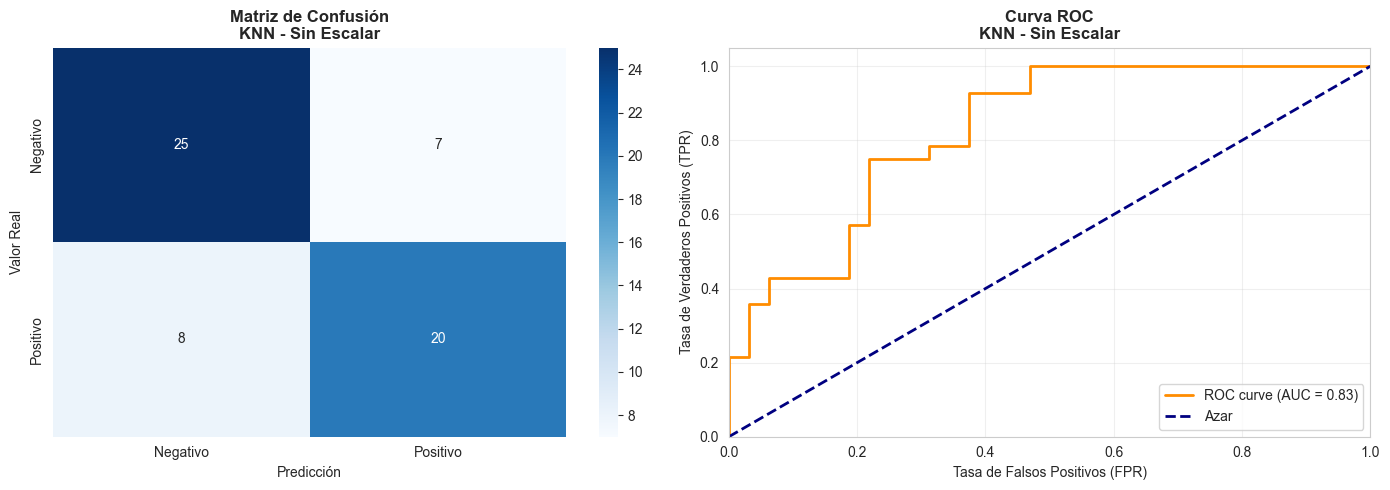


📌 Configuración: Standard

📊 REPORTE DE EVALUACIÓN: KNN - Standard

📈 MÉTRICAS DE CLASIFICACIÓN:
   • Accuracy:       0.8500
   • Precision:      0.8519
   • Recall:         0.8214
   • F1-Score:       0.8364
   • Especificidad:  0.8750
   • AUC-ROC:        0.9498

📋 MATRIZ DE CONFUSIÓN:
   TN: 28  FP: 4
   FN: 5  TP: 23


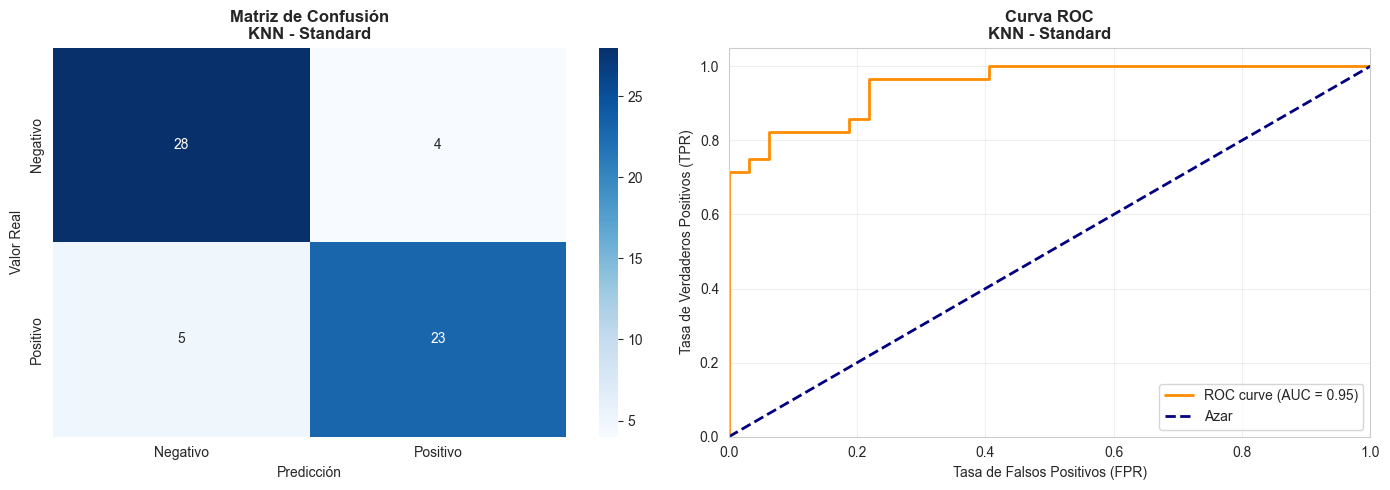


📌 Configuración: Robust

📊 REPORTE DE EVALUACIÓN: KNN - Robust

📈 MÉTRICAS DE CLASIFICACIÓN:
   • Accuracy:       0.8500
   • Precision:      0.8800
   • Recall:         0.7857
   • F1-Score:       0.8302
   • Especificidad:  0.9062
   • AUC-ROC:        0.9208

📋 MATRIZ DE CONFUSIÓN:
   TN: 29  FP: 3
   FN: 6  TP: 22


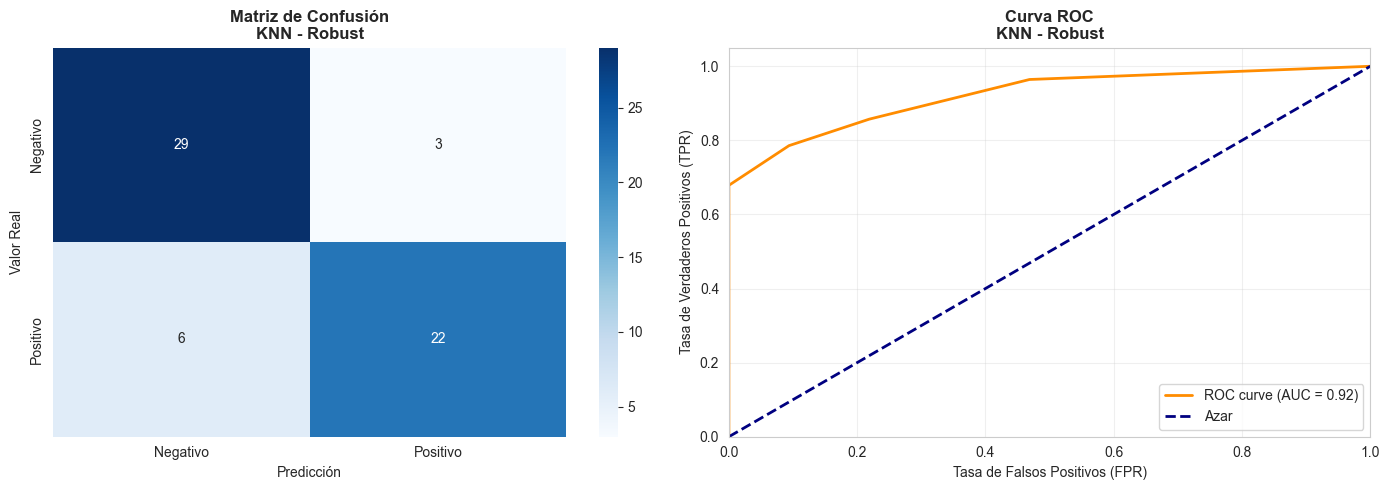


📌 Configuración: MinMax

📊 REPORTE DE EVALUACIÓN: KNN - MinMax

📈 MÉTRICAS DE CLASIFICACIÓN:
   • Accuracy:       0.8500
   • Precision:      0.8800
   • Recall:         0.7857
   • F1-Score:       0.8302
   • Especificidad:  0.9062
   • AUC-ROC:        0.9235

📋 MATRIZ DE CONFUSIÓN:
   TN: 29  FP: 3
   FN: 6  TP: 22


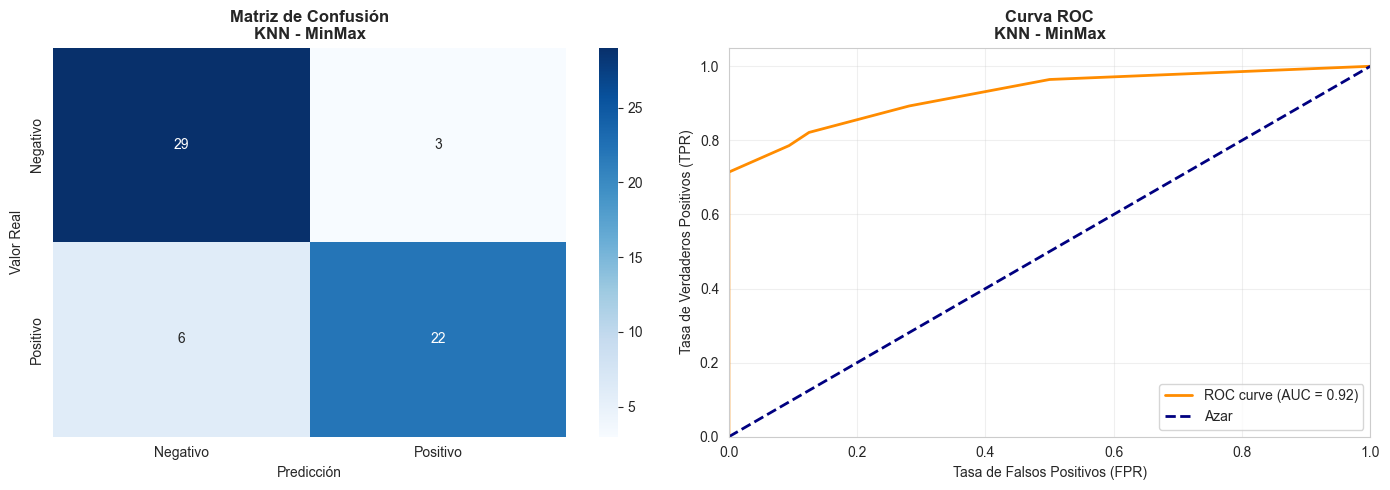


🔹 EVALUACIÓN: REGRESIÓN LOGÍSTICA - CLASIFICACIÓN

📌 Configuración: Sin Escalar

📊 REPORTE DE EVALUACIÓN: Regresión Logística - Sin Escalar

📈 MÉTRICAS DE CLASIFICACIÓN:
   • Accuracy:       0.8667
   • Precision:      0.9167
   • Recall:         0.7857
   • F1-Score:       0.8462
   • Especificidad:  0.9375
   • AUC-ROC:        0.9587

📋 MATRIZ DE CONFUSIÓN:
   TN: 30  FP: 2
   FN: 6  TP: 22


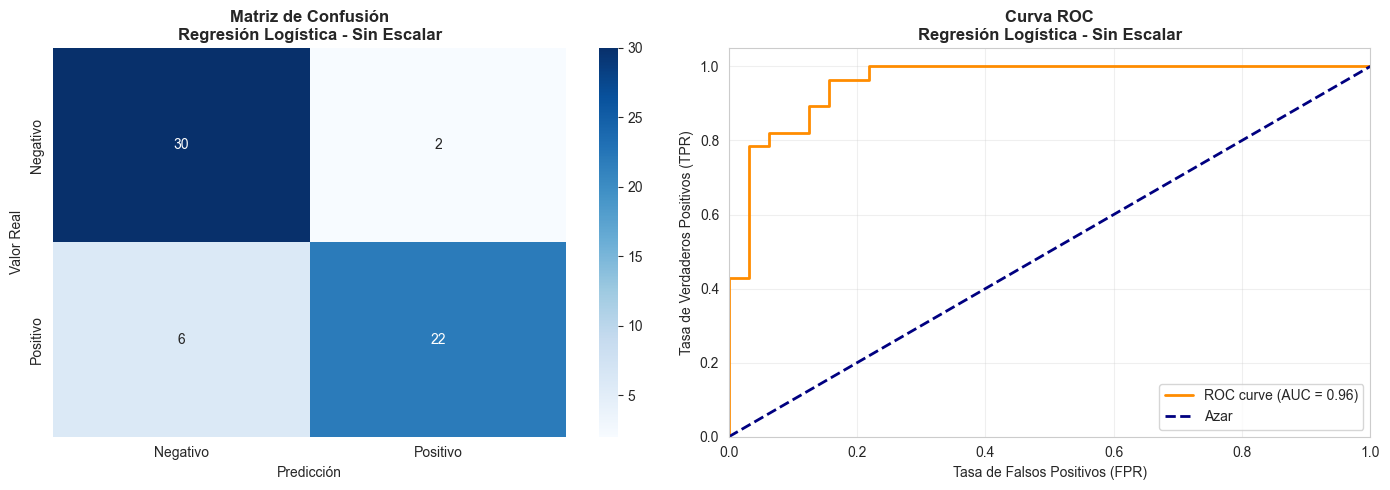


📌 Configuración: Standard

📊 REPORTE DE EVALUACIÓN: Regresión Logística - Standard

📈 MÉTRICAS DE CLASIFICACIÓN:
   • Accuracy:       0.8500
   • Precision:      0.8800
   • Recall:         0.7857
   • F1-Score:       0.8302
   • Especificidad:  0.9062
   • AUC-ROC:        0.9509

📋 MATRIZ DE CONFUSIÓN:
   TN: 29  FP: 3
   FN: 6  TP: 22


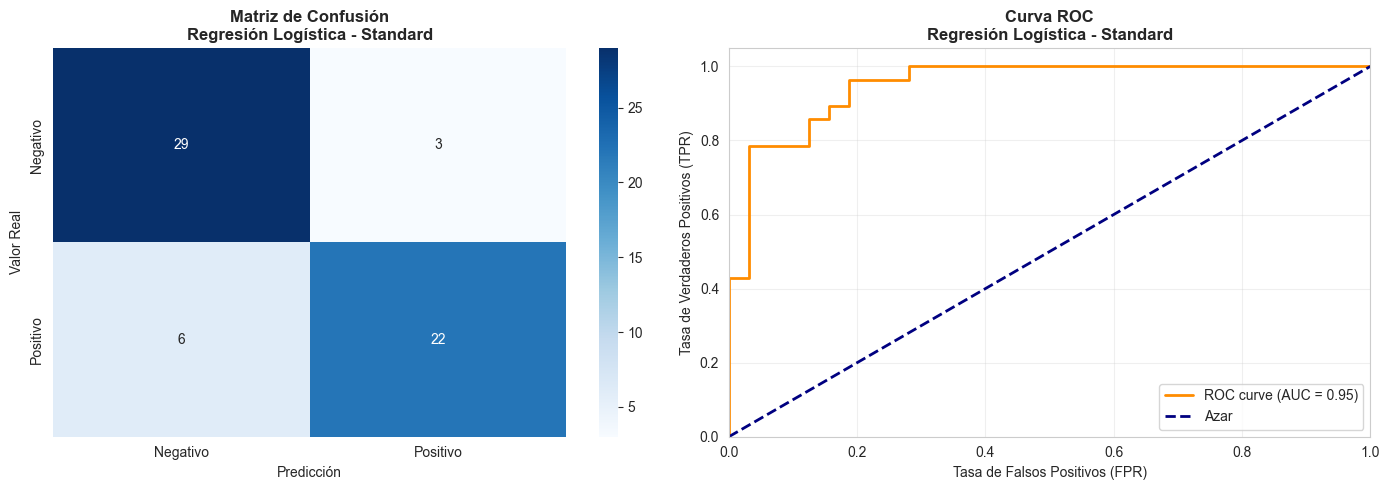


📌 Configuración: Robust

📊 REPORTE DE EVALUACIÓN: Regresión Logística - Robust

📈 MÉTRICAS DE CLASIFICACIÓN:
   • Accuracy:       0.8500
   • Precision:      0.8800
   • Recall:         0.7857
   • F1-Score:       0.8302
   • Especificidad:  0.9062
   • AUC-ROC:        0.9509

📋 MATRIZ DE CONFUSIÓN:
   TN: 29  FP: 3
   FN: 6  TP: 22


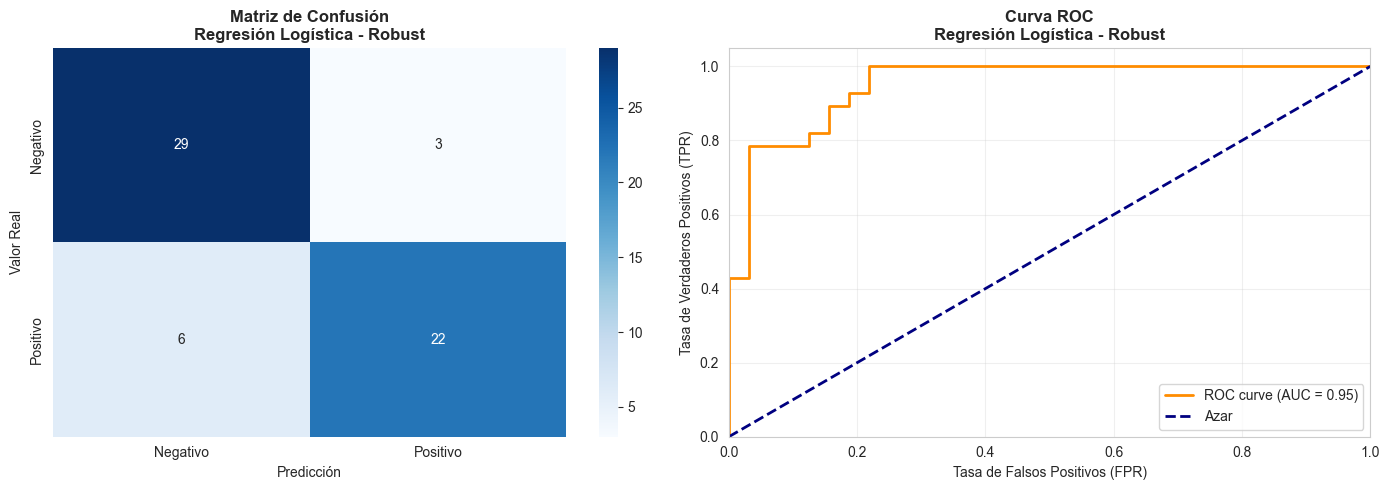


📌 Configuración: MinMax

📊 REPORTE DE EVALUACIÓN: Regresión Logística - MinMax

📈 MÉTRICAS DE CLASIFICACIÓN:
   • Accuracy:       0.8333
   • Precision:      0.8462
   • Recall:         0.7857
   • F1-Score:       0.8148
   • Especificidad:  0.8750
   • AUC-ROC:        0.9531

📋 MATRIZ DE CONFUSIÓN:
   TN: 28  FP: 4
   FN: 6  TP: 22


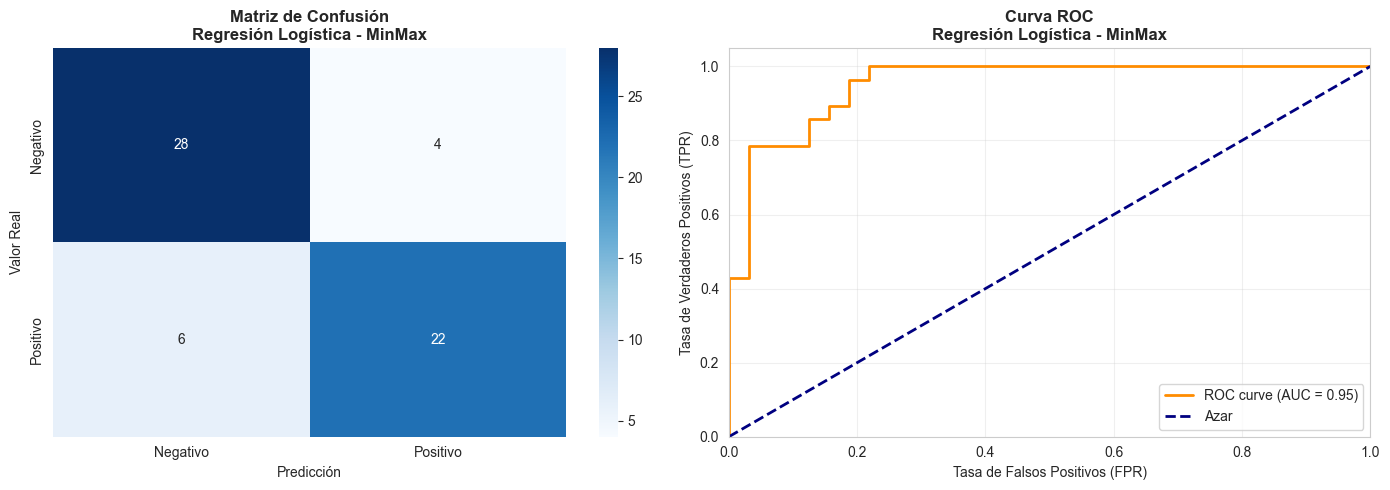

In [29]:
# ============================================================================
# 5.2 EVALUACIÓN DE MODELOS DE CLASIFICACIÓN EN TEST
# ============================================================================
print("\n" + "="*60)
print("🎯 EVALUACIÓN DE MODELOS DE CLASIFICACIÓN EN TEST")
print("="*60)

# Diccionario para almacenar todas las métricas
metricas_test_clf = {}

# Configuraciones de datos de test para clasificación
configuraciones_test_clf = {
    'Sin Escalar': X_test_clf_sin_escala,
    'Standard': X_test_clf_standard,
    'Robust': X_test_clf_robust,
    'MinMax': X_test_clf_minmax
}

# ============================================================================
# EVALUAR KNN - CLASIFICACIÓN
# ============================================================================
print("\n" + "="*60)
print("🔹 EVALUACIÓN: KNN - CLASIFICACIÓN")
print("="*60)

metricas_test_clf['KNN'] = {}

for nombre_config, X_test_escalado in configuraciones_test_clf.items():
    print(f"\n{'='*60}")
    print(f"📌 Configuración: {nombre_config}")
    print(f"{'='*60}")

    # TODO: Obtén el mejor modelo entrenado de resultados_clf
    mejor_modelo = resultados_clf['KNN'][nombre_config]['grid_search'].best_estimator_

    # Evaluar modelo
    metricas = evaluar_clasificador(
        modelo=mejor_modelo,
        X_test=X_test_escalado,
        y_test=y_test_clf,
        nombre_modelo=f"KNN - {nombre_config}",
        mostrar_graficos=True
    )

    # Guardar métricas
    metricas_test_clf['KNN'][nombre_config] = metricas

# ============================================================================
# EVALUAR REGRESIÓN LOGÍSTICA - CLASIFICACIÓN
# ============================================================================
print("\n" + "="*60)
print("🔹 EVALUACIÓN: REGRESIÓN LOGÍSTICA - CLASIFICACIÓN")
print("="*60)

metricas_test_clf['Logistic'] = {}

for nombre_config, X_test_escalado in configuraciones_test_clf.items():
    print(f"\n{'='*60}")
    print(f"📌 Configuración: {nombre_config}")
    print(f"{'='*60}")

    # TODO: Obtén el mejor modelo entrenado de resultados_clf
    mejor_modelo = resultados_clf['Logistic'][nombre_config]['grid_search'].best_estimator_

    # Evaluar modelo
    metricas = evaluar_clasificador(
        modelo=mejor_modelo,
        X_test=X_test_escalado,
        y_test=y_test_clf,
        nombre_modelo=f"Regresión Logística - {nombre_config}",
        mostrar_graficos=True
    )

    # Guardar métricas
    metricas_test_clf['Logistic'][nombre_config] = metricas


📊 TABLA COMPARATIVA DE RESULTADOS - CLASIFICACIÓN

📋 Tabla de Resultados (ordenada por F1-Score):
  Modelo Escalamiento  Accuracy  Precision   Recall  F1-Score  Especificidad  AUC-ROC
Logistic  Sin Escalar  0.866667   0.916667 0.785714  0.846154        0.93750 0.958705
     KNN     Standard  0.850000   0.851852 0.821429  0.836364        0.87500 0.949777
     KNN       MinMax  0.850000   0.880000 0.785714  0.830189        0.90625 0.923549
     KNN       Robust  0.850000   0.880000 0.785714  0.830189        0.90625 0.920759
Logistic       Robust  0.850000   0.880000 0.785714  0.830189        0.90625 0.950893
Logistic     Standard  0.850000   0.880000 0.785714  0.830189        0.90625 0.950893
Logistic       MinMax  0.833333   0.846154 0.785714  0.814815        0.87500 0.953125
     KNN  Sin Escalar  0.750000   0.740741 0.714286  0.727273        0.78125 0.827009

📊 Gráfico comparativo de métricas


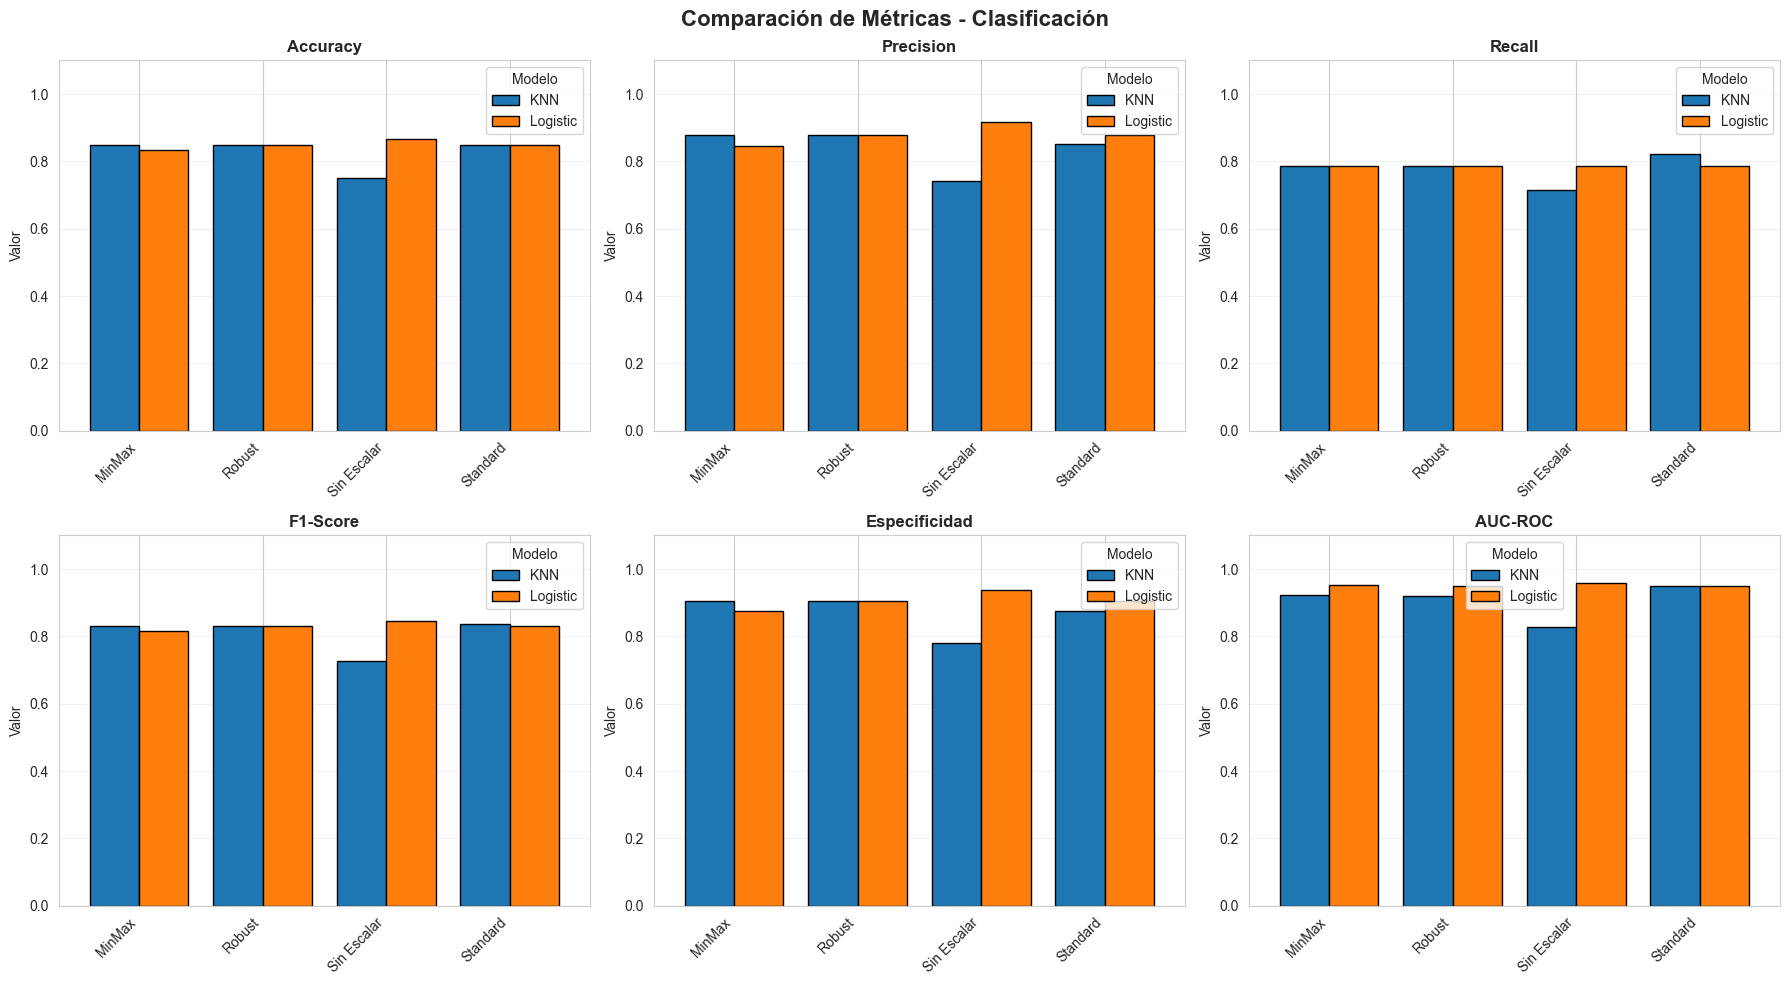

In [32]:
# ============================================================================
# 5.3 TABLA COMPARATIVA - CLASIFICACIÓN
# ============================================================================
print("\n" + "="*60)
print("📊 TABLA COMPARATIVA DE RESULTADOS - CLASIFICACIÓN")
print("="*60)

# Crear DataFrame con todas las métricas
datos_tabla_clf = []

for modelo in metricas_test_clf.keys():
    for config in metricas_test_clf[modelo].keys():
        metricas = metricas_test_clf[modelo][config]
        datos_tabla_clf.append({
            'Modelo': modelo,
            'Escalamiento': config,
            'Accuracy': metricas['accuracy'],
            'Precision': metricas['precision'],
            'Recall': metricas['recall'],
            'F1-Score': metricas['f1_score'],
            'Especificidad': metricas['especificidad'],
            'AUC-ROC': metricas['auc_roc']
        })

# TODO: Crea un DataFrame con los datos
df_resultados_clf = pd.DataFrame(datos_tabla_clf)

# Ordenar por F1-Score (o la métrica que prefieras)
df_resultados_clf = df_resultados_clf.sort_values(by='F1-Score', ascending=False)

print("\n📋 Tabla de Resultados (ordenada por F1-Score):")
print(df_resultados_clf.to_string(index=False))

# Guardar en CSV (opcional)
# df_resultados_clf.to_csv('resultados_clasificacion.csv', index=False)
# print("\n✅ Tabla guardada en 'resultados_clasificacion.csv'")

# ============================================================================
# VISUALIZACIÓN COMPARATIVA - CLASIFICACIÓN
# ============================================================================
print("\n📊 Gráfico comparativo de métricas")

# Preparar datos para visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparación de Métricas - Clasificación', fontsize=16, fontweight='bold')

metricas_viz = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Especificidad', 'AUC-ROC']

for idx, metrica in enumerate(metricas_viz):
    ax = axes[idx // 3, idx % 3]

    # Crear gráfico de barras agrupadas
    datos_metrica = df_resultados_clf.pivot(index='Escalamiento',
                                             columns='Modelo',
                                             values=metrica)

    datos_metrica.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_xlabel('')
    ax.legend(title='Modelo', loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])

    # Rotar etiquetas del eje x
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


🎯 EVALUACIÓN DE MODELOS DE REGRESIÓN EN TEST

🔹 EVALUACIÓN: KNN - REGRESIÓN

📌 Configuración: Sin Escalar

📊 REPORTE DE EVALUACIÓN: KNN - Sin Escalar

📈 MÉTRICAS DE REGRESIÓN:
   • RMSE (Root Mean Squared Error):     5.5774
   • MAE (Mean Absolute Error):          4.1175
   • MSE (Mean Squared Error):           31.1079
   • R² (Coeficiente de Determinación):  0.9308


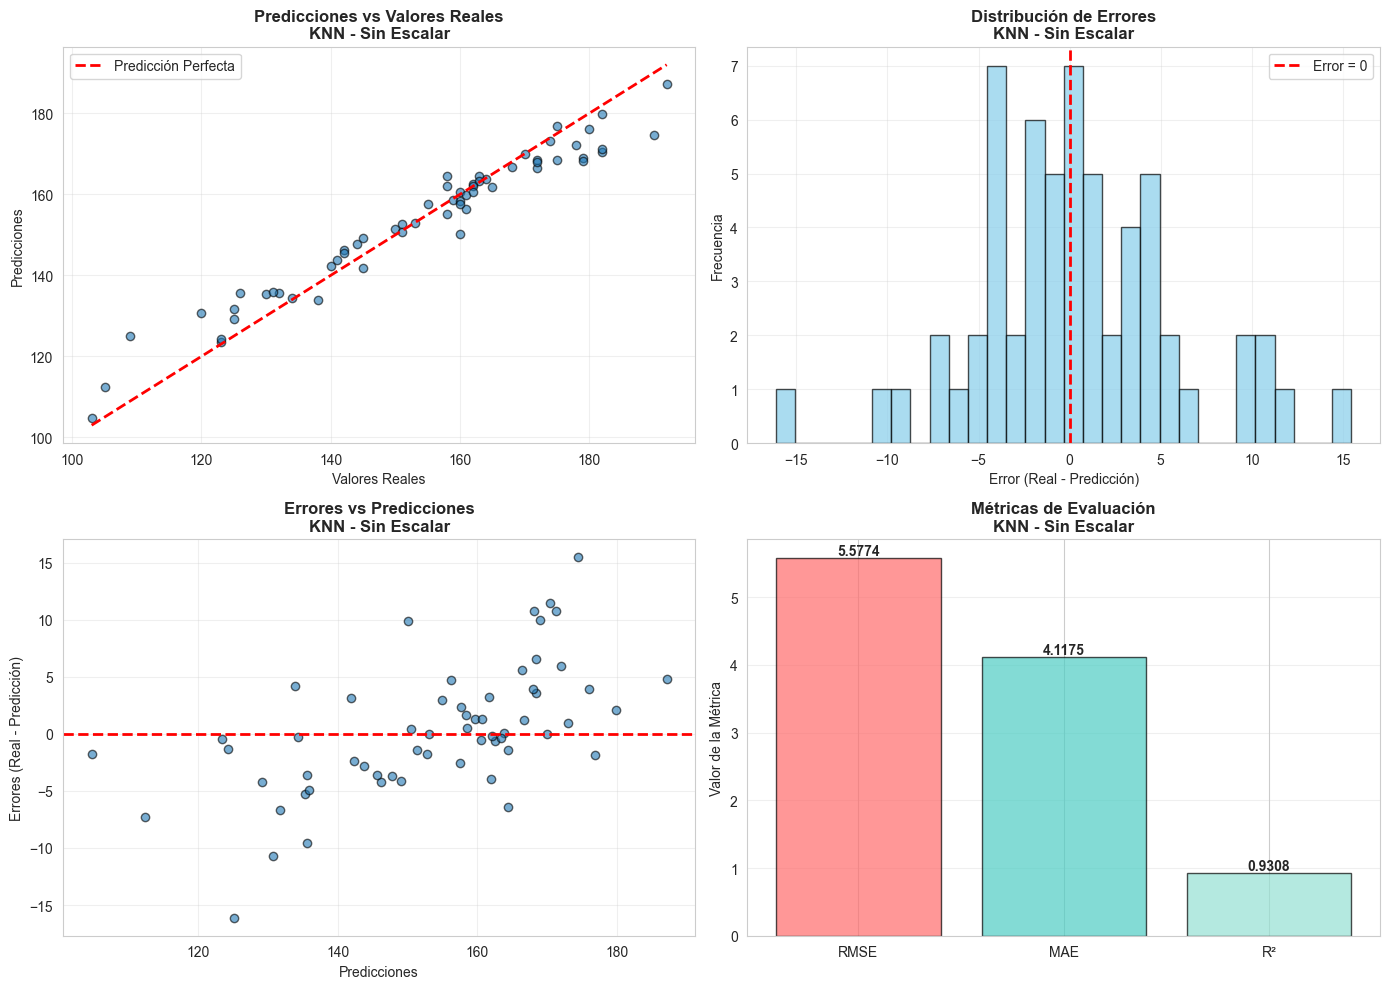


📌 Configuración: Standard

📊 REPORTE DE EVALUACIÓN: KNN - Standard

📈 MÉTRICAS DE REGRESIÓN:
   • RMSE (Root Mean Squared Error):     12.0554
   • MAE (Mean Absolute Error):          9.2684
   • MSE (Mean Squared Error):           145.3335
   • R² (Coeficiente de Determinación):  0.6765


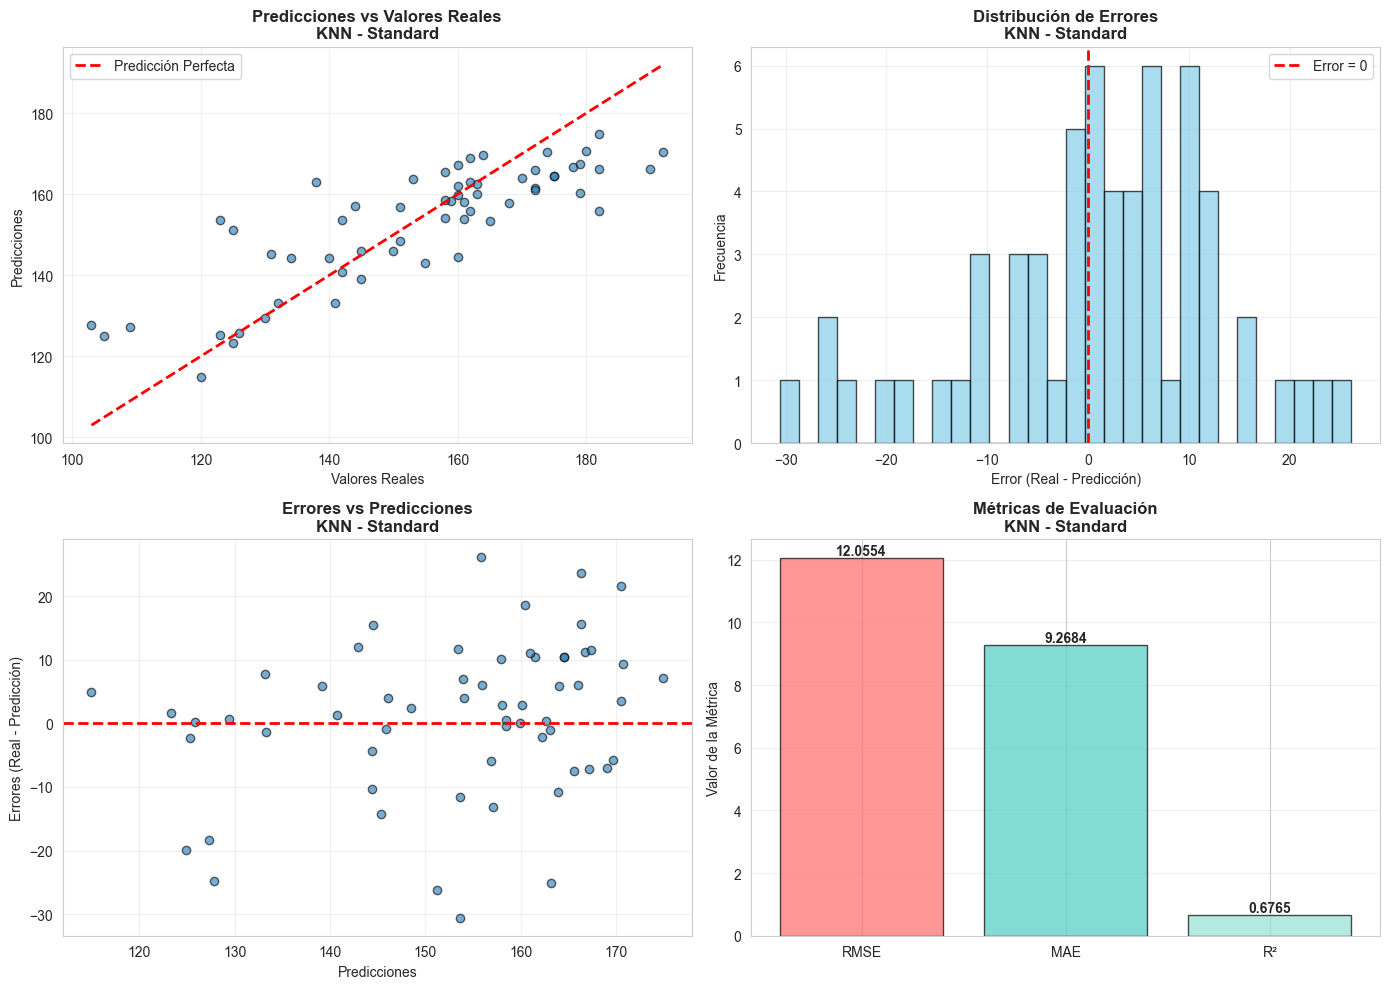


📌 Configuración: Robust

📊 REPORTE DE EVALUACIÓN: KNN - Robust

📈 MÉTRICAS DE REGRESIÓN:
   • RMSE (Root Mean Squared Error):     10.5999
   • MAE (Mean Absolute Error):          8.7011
   • MSE (Mean Squared Error):           112.3571
   • R² (Coeficiente de Determinación):  0.7499


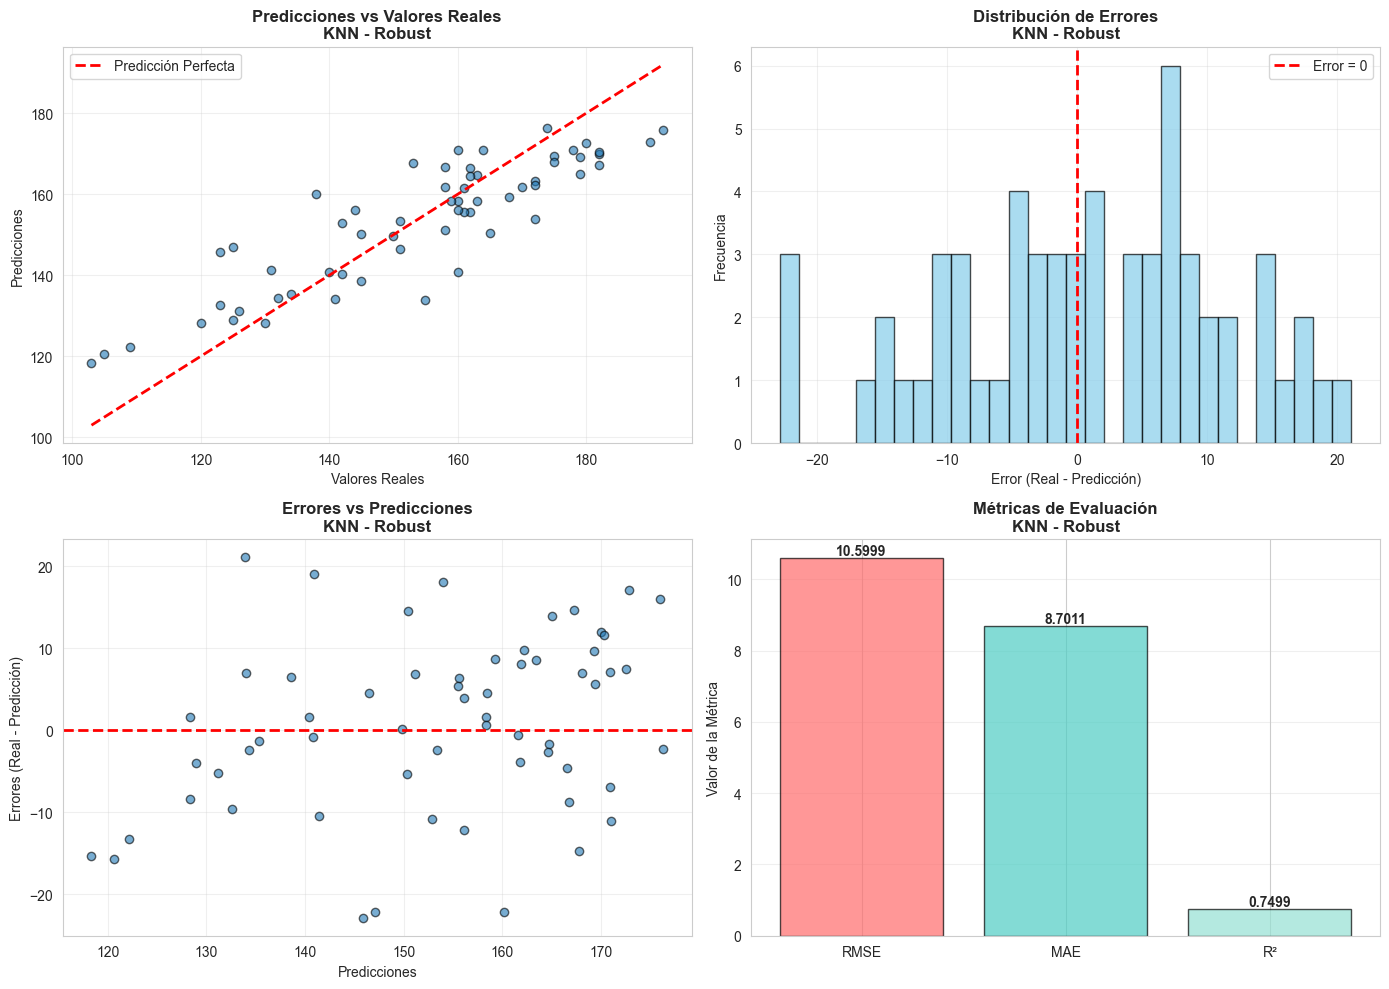


📌 Configuración: MinMax

📊 REPORTE DE EVALUACIÓN: KNN - MinMax

📈 MÉTRICAS DE REGRESIÓN:
   • RMSE (Root Mean Squared Error):     14.2359
   • MAE (Mean Absolute Error):          11.0321
   • MSE (Mean Squared Error):           202.6606
   • R² (Coeficiente de Determinación):  0.5489


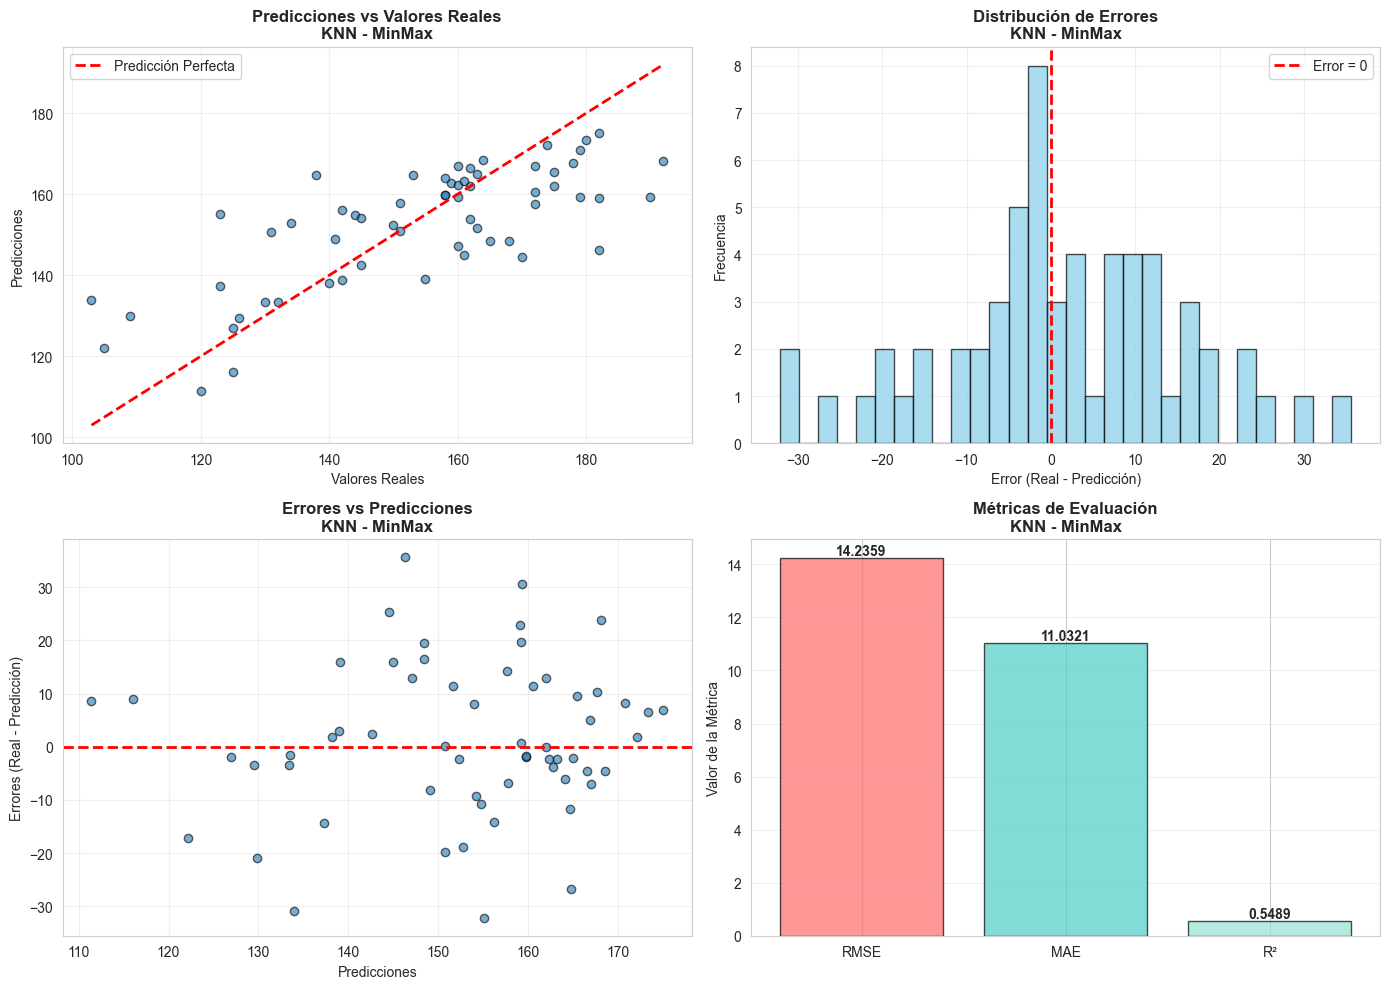


🔹 EVALUACIÓN: RIDGE - REGRESIÓN

📌 Configuración: Sin Escalar

📊 REPORTE DE EVALUACIÓN: Ridge - Sin Escalar

📈 MÉTRICAS DE REGRESIÓN:
   • RMSE (Root Mean Squared Error):     0.0000
   • MAE (Mean Absolute Error):          0.0000
   • MSE (Mean Squared Error):           0.0000
   • R² (Coeficiente de Determinación):  1.0000


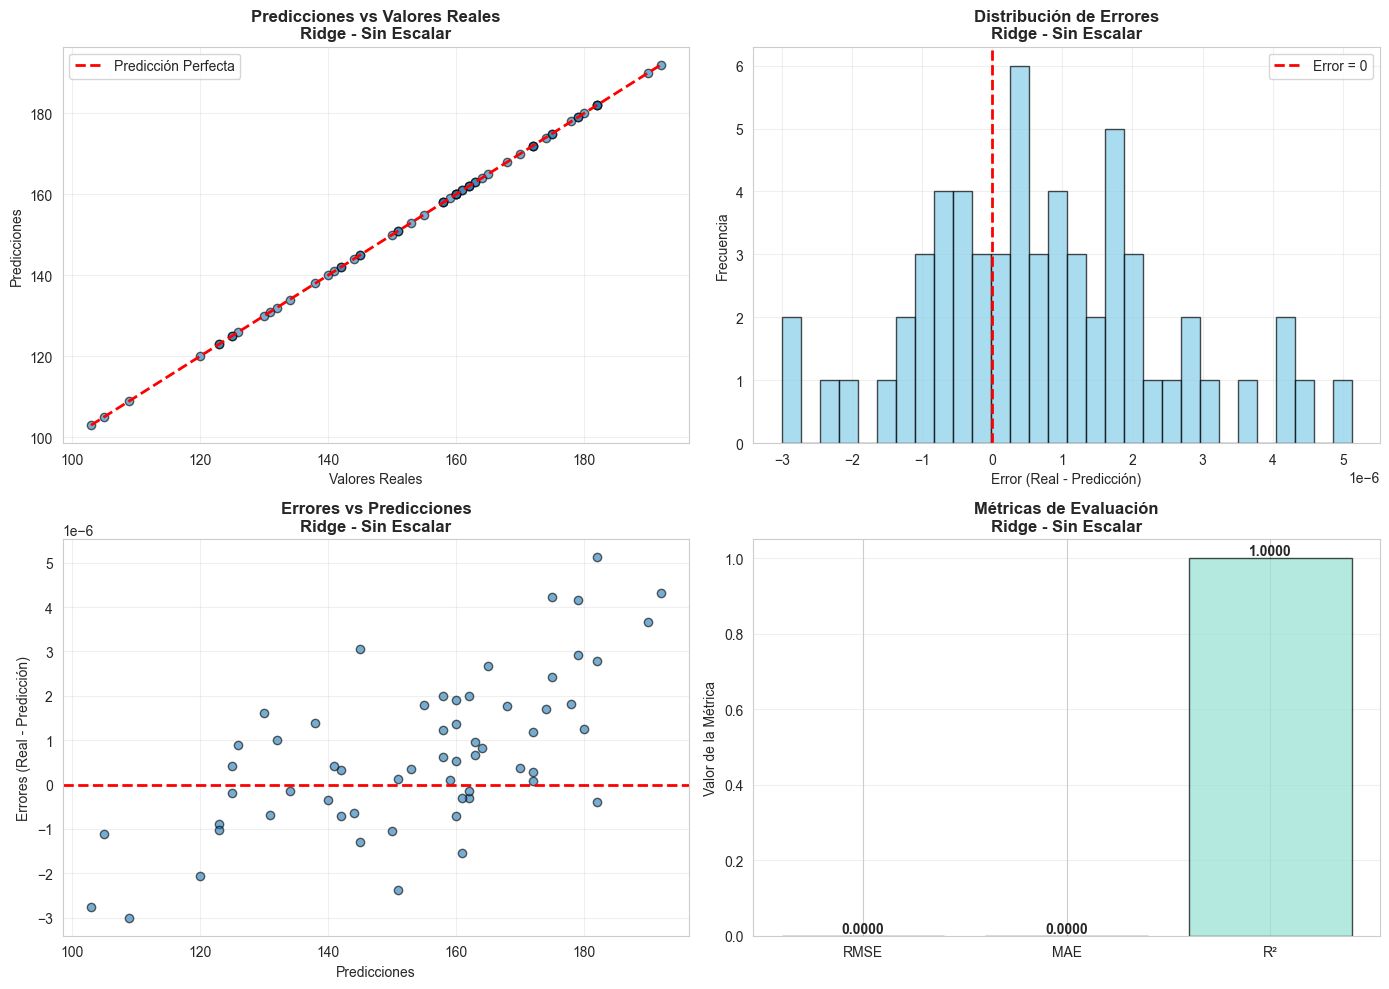


📌 Configuración: Standard

📊 REPORTE DE EVALUACIÓN: Ridge - Standard

📈 MÉTRICAS DE REGRESIÓN:
   • RMSE (Root Mean Squared Error):     0.0012
   • MAE (Mean Absolute Error):          0.0010
   • MSE (Mean Squared Error):           0.0000
   • R² (Coeficiente de Determinación):  1.0000


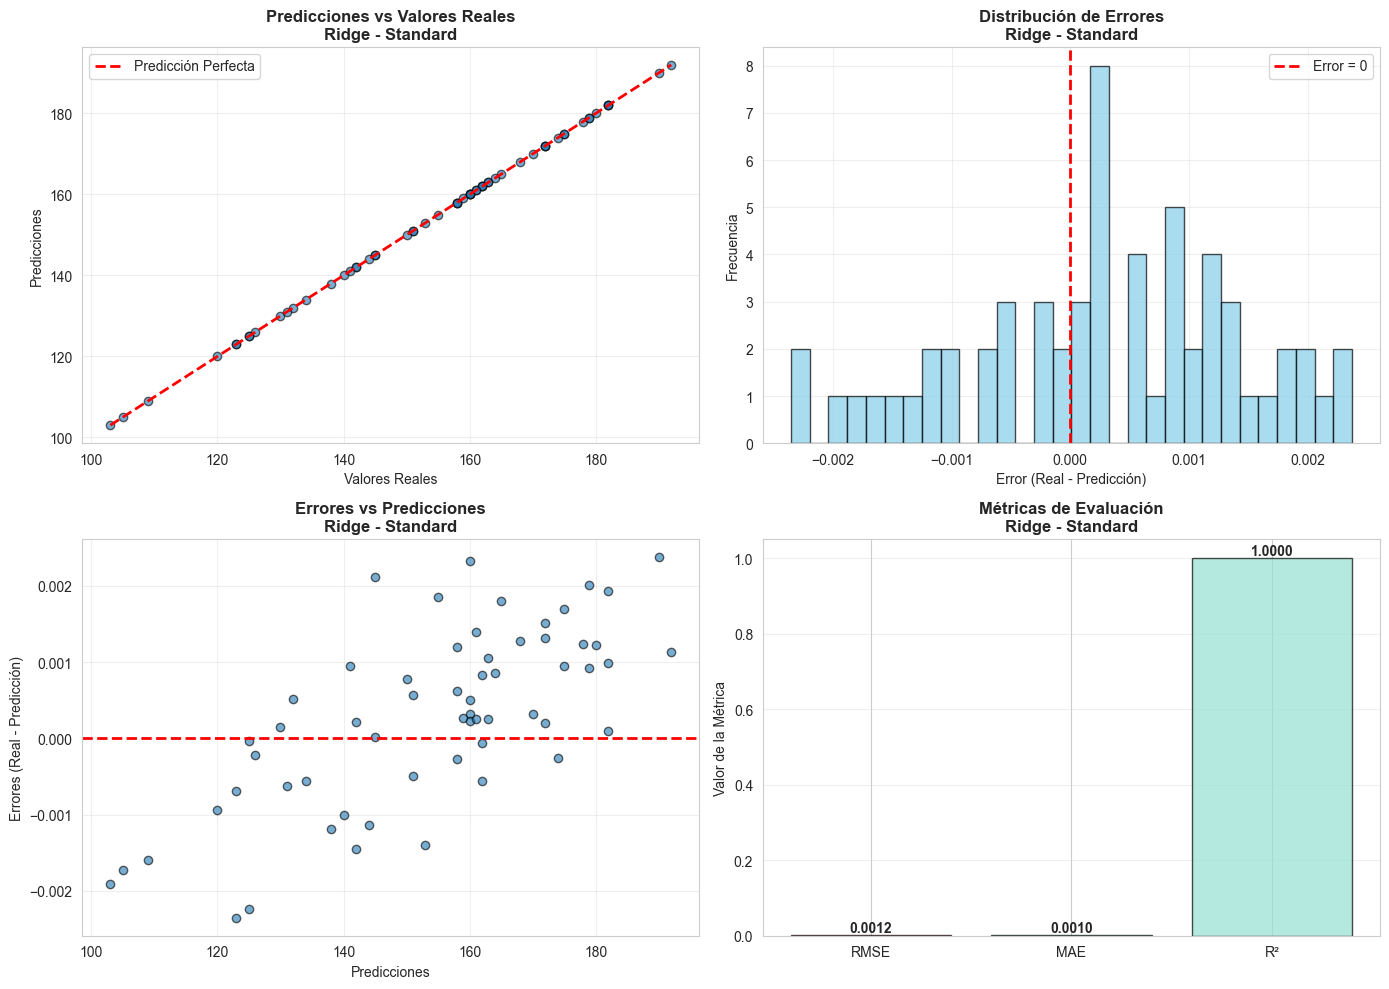


📌 Configuración: Robust

📊 REPORTE DE EVALUACIÓN: Ridge - Robust

📈 MÉTRICAS DE REGRESIÓN:
   • RMSE (Root Mean Squared Error):     0.0024
   • MAE (Mean Absolute Error):          0.0020
   • MSE (Mean Squared Error):           0.0000
   • R² (Coeficiente de Determinación):  1.0000


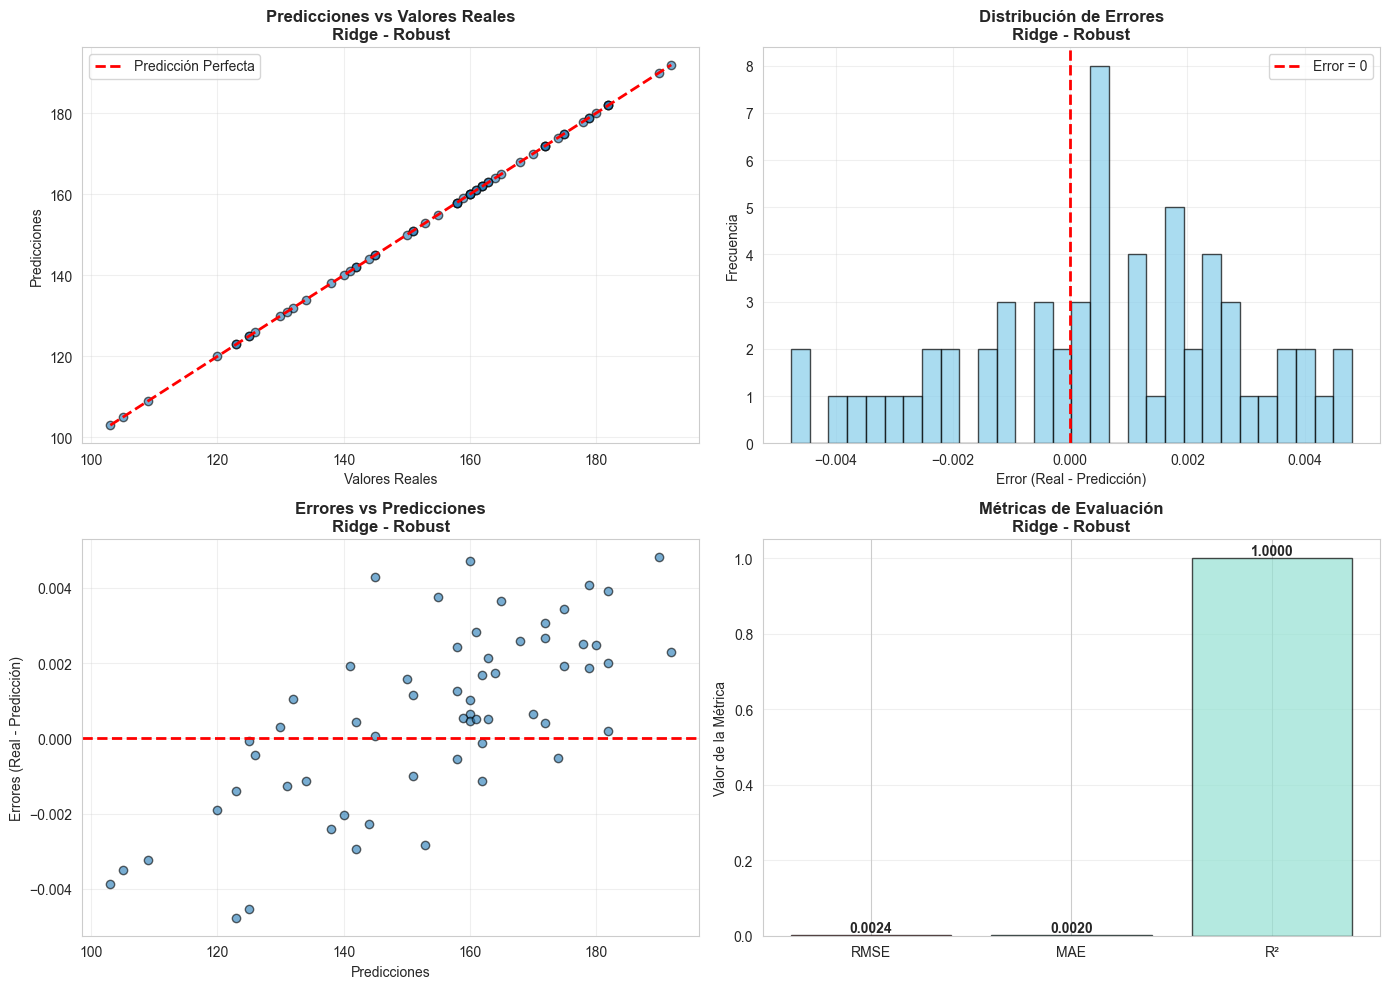


📌 Configuración: MinMax

📊 REPORTE DE EVALUACIÓN: Ridge - MinMax

📈 MÉTRICAS DE REGRESIÓN:
   • RMSE (Root Mean Squared Error):     0.0379
   • MAE (Mean Absolute Error):          0.0313
   • MSE (Mean Squared Error):           0.0014
   • R² (Coeficiente de Determinación):  1.0000


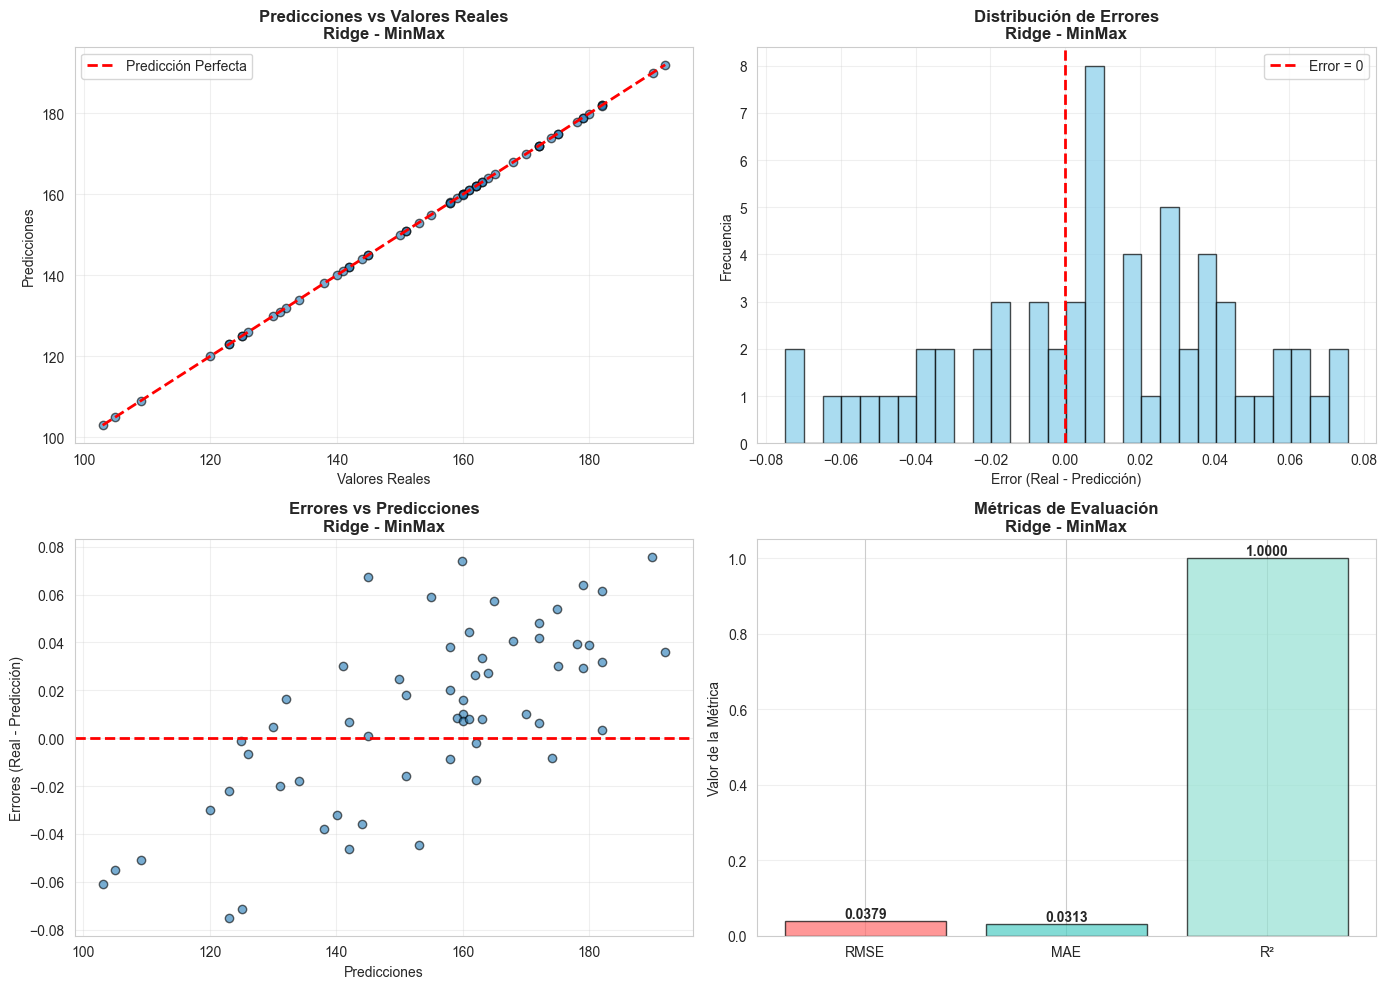

In [33]:
# ============================================================================
# 5.4 EVALUACIÓN DE MODELOS DE REGRESIÓN EN TEST
# ============================================================================
print("\n" + "="*60)
print("🎯 EVALUACIÓN DE MODELOS DE REGRESIÓN EN TEST")
print("="*60)

# Diccionario para almacenar todas las métricas
metricas_test_reg = {}

# Configuraciones de datos de test para regresión
configuraciones_test_reg = {
    'Sin Escalar': X_test_reg_sin_escala,
    'Standard': X_test_reg_standard,
    'Robust': X_test_reg_robust,
    'MinMax': X_test_reg_minmax
}

# ============================================================================
# EVALUAR KNN - REGRESIÓN
# ============================================================================
print("\n" + "="*60)
print("🔹 EVALUACIÓN: KNN - REGRESIÓN")
print("="*60)

metricas_test_reg['KNN'] = {}

for nombre_config, X_test_escalado in configuraciones_test_reg.items():
    print(f"\n{'='*60}")
    print(f"📌 Configuración: {nombre_config}")
    print(f"{'='*60}")

    # TODO: Obtén el mejor modelo entrenado de resultados_reg
    mejor_modelo = resultados_reg['KNN'][nombre_config]['grid_search'].best_estimator_

    # Evaluar modelo
    metricas = evaluar_regresor(
        modelo=mejor_modelo,
        X_test=X_test_escalado,
        y_test=y_test_reg,
        nombre_modelo=f"KNN - {nombre_config}",
        mostrar_graficos=True
    )

    # Guardar métricas
    metricas_test_reg['KNN'][nombre_config] = metricas

# ============================================================================
# EVALUAR RIDGE - REGRESIÓN
# ============================================================================
print("\n" + "="*60)
print("🔹 EVALUACIÓN: RIDGE - REGRESIÓN")
print("="*60)

metricas_test_reg['Ridge'] = {}

for nombre_config, X_test_escalado in configuraciones_test_reg.items():
    print(f"\n{'='*60}")
    print(f"📌 Configuración: {nombre_config}")
    print(f"{'='*60}")

    # TODO: Obtén el mejor modelo entrenado de resultados_reg
    mejor_modelo = resultados_reg['Ridge'][nombre_config]['grid_search'].best_estimator_

    # Evaluar modelo
    metricas = evaluar_regresor(
        modelo=mejor_modelo,
        X_test=X_test_escalado,
        y_test=y_test_reg,
        nombre_modelo=f"Ridge - {nombre_config}",
        mostrar_graficos=True
    )

    # Guardar métricas
    metricas_test_reg['Ridge'][nombre_config] = metricas


📊 TABLA COMPARATIVA DE RESULTADOS - REGRESIÓN

📋 Tabla de Resultados (ordenada por RMSE - menor es mejor):
Modelo Escalamiento      RMSE       MAE          MSE       R²
 Ridge  Sin Escalar  0.000002  0.000001 3.493623e-12 1.000000
 Ridge     Standard  0.001191  0.000983 1.418378e-06 1.000000
 Ridge       Robust  0.002413  0.001992 5.823095e-06 1.000000
 Ridge       MinMax  0.037930  0.031308 1.438648e-03 0.999997
   KNN  Sin Escalar  5.577447  4.117523 3.110791e+01 0.930761
   KNN       Robust 10.599865  8.701142 1.123571e+02 0.749919
   KNN     Standard 12.055433  9.268418 1.453335e+02 0.676521
   KNN       MinMax 14.235891 11.032096 2.026606e+02 0.548924

📊 Gráfico comparativo de métricas


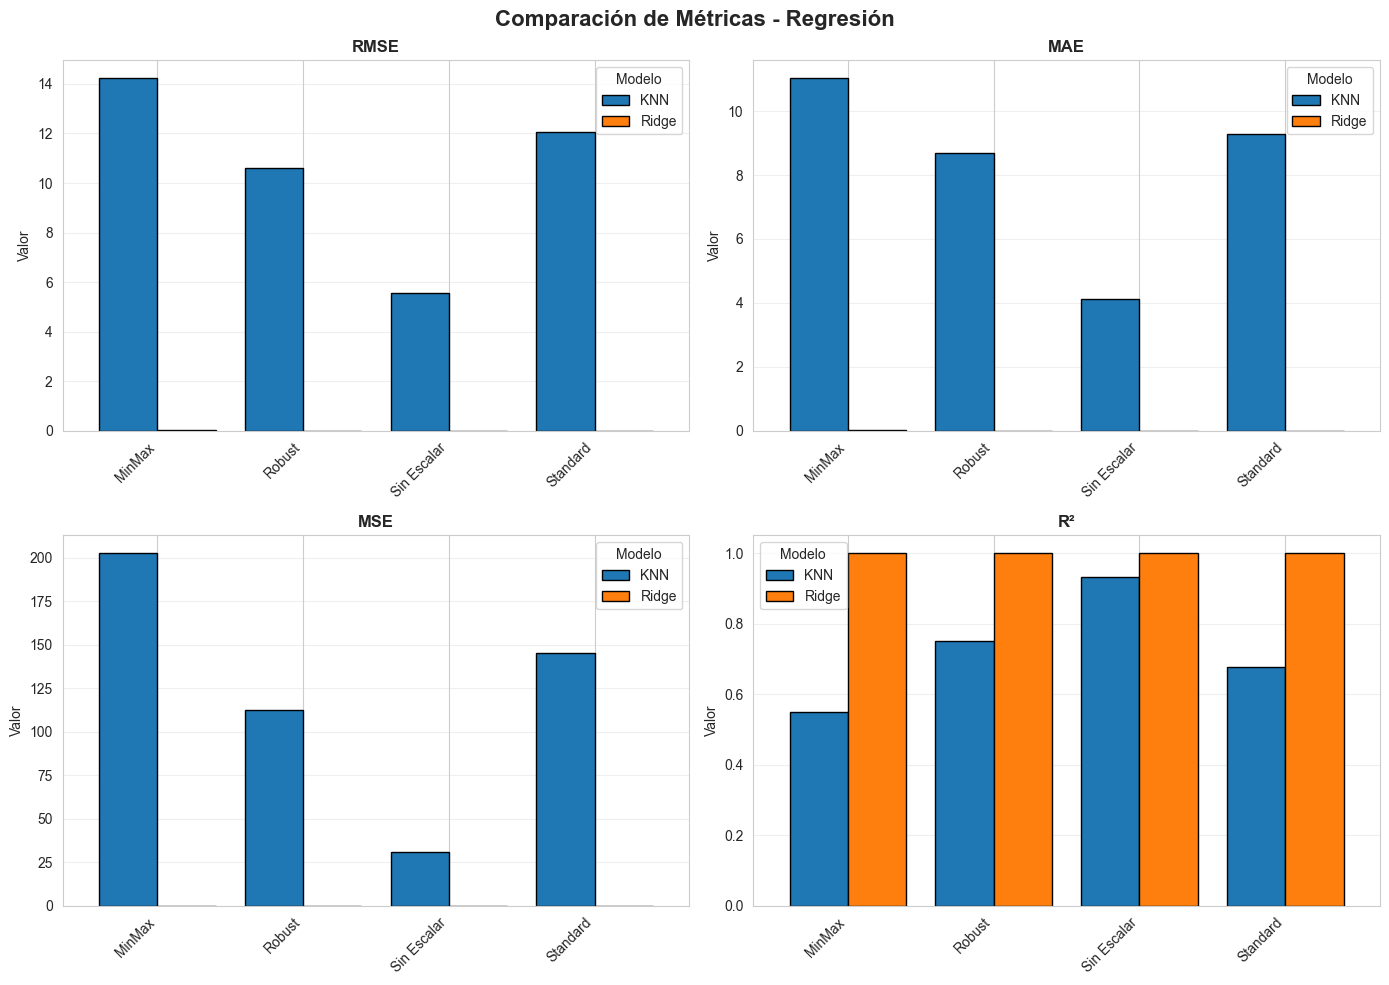

In [38]:
# ============================================================================
# 5.5 TABLA COMPARATIVA - REGRESIÓN
# ============================================================================
print("\n" + "="*60)
print("📊 TABLA COMPARATIVA DE RESULTADOS - REGRESIÓN")
print("="*60)

# Crear DataFrame con todas las métricas
datos_tabla_reg = []

for modelo in metricas_test_reg.keys():
    for config in metricas_test_reg[modelo].keys():
        metricas = metricas_test_reg[modelo][config]
        datos_tabla_reg.append({
            'Modelo': modelo,
            'Escalamiento': config,
            'RMSE': metricas['rmse'],
            'MAE': metricas['mae'],
            'MSE': metricas['mse'],
            'R²': metricas['r2']
        })

# TODO: Crea un DataFrame con los datos
df_resultados_reg = pd.DataFrame(datos_tabla_reg)

# TODO: Ordena por RMSE (menor es mejor)
df_resultados_reg = df_resultados_reg.sort_values(by='RMSE', ascending=True)

print("\n📋 Tabla de Resultados (ordenada por RMSE - menor es mejor):")
print(df_resultados_reg.to_string(index=False))

# Guardar en CSV (opcional)
# df_resultados_reg.to_csv('resultados_regresion.csv', index=False)
# print("\n✅ Tabla guardada en 'resultados_regresion.csv'")

# ============================================================================
# VISUALIZACIÓN COMPARATIVA - REGRESIÓN
# ============================================================================
print("\n📊 Gráfico comparativo de métricas")

# Preparar datos para visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación de Métricas - Regresión', fontsize=16, fontweight='bold')

metricas_viz_reg = ['RMSE', 'MAE', 'MSE', 'R²']

for idx, metrica in enumerate(metricas_viz_reg):
    ax = axes[idx // 2, idx % 2]

    # Crear gráfico de barras agrupadas
    datos_metrica = df_resultados_reg.pivot(index='Escalamiento',
                                             columns='Modelo',
                                             values=metrica)

    datos_metrica.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_xlabel('')
    ax.legend(title='Modelo', loc='best')
    ax.grid(axis='y', alpha=0.3)

    # Rotar etiquetas del eje x
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [39]:
# ============================================================================
# 5.6 RESUMEN FINAL Y RECOMENDACIONES
# ============================================================================
print("\n" + "="*60)
print("🏆 RESUMEN FINAL Y RECOMENDACIONES")
print("="*60)

# Mejor modelo de clasificación
mejor_clf = df_resultados_clf.iloc[0]
print("\n🎯 CLASIFICACIÓN:")
print(f"   🥇 Mejor Modelo: {mejor_clf['Modelo']} con {mejor_clf['Escalamiento']}")
print(f"   📊 Métricas:")
print(f"      • Accuracy: {mejor_clf['Accuracy']:.4f}")
print(f"      • F1-Score: {mejor_clf['F1-Score']:.4f}")
print(f"      • AUC-ROC: {mejor_clf['AUC-ROC']:.4f}")

# Mejor modelo de regresión
mejor_reg = df_resultados_reg.iloc[0]
print("\n🎯 REGRESIÓN:")
print(f"   🥇 Mejor Modelo: {mejor_reg['Modelo']} con {mejor_reg['Escalamiento']}")
print(f"   📊 Métricas:")
print(f"      • RMSE: {mejor_reg['RMSE']:.4f}")
print(f"      • MAE: {mejor_reg['MAE']:.4f}")
print(f"      • R²: {mejor_reg['R²']:.4f}")

print("\n" + "="*60)
print("✅ EVALUACIÓN COMPLETA FINALIZADA")
print("="*60)

print("""
📌 CONCLUSIONES:
   1. Compara las métricas entre modelos y configuraciones
   2. Considera el trade-off entre métricas (ej: precision vs recall)
   3. El escalamiento puede tener impacto significativo en algunos modelos
   4. KNN es sensible al escalamiento, Ridge/Logistic pueden serlo también

💡 PRÓXIMOS PASOS SUGERIDOS:
   1. Probar otros algoritmos (SVM, Random Forest, etc.)
   2. Analizar errores para identificar patrones
   3. Realizar feature engineering si es necesario
   4. Implementar el mejor modelo en producción
""")


🏆 RESUMEN FINAL Y RECOMENDACIONES

🎯 CLASIFICACIÓN:
   🥇 Mejor Modelo: Logistic con Sin Escalar
   📊 Métricas:
      • Accuracy: 0.8667
      • F1-Score: 0.8462
      • AUC-ROC: 0.9587

🎯 REGRESIÓN:
   🥇 Mejor Modelo: Ridge con Sin Escalar
   📊 Métricas:
      • RMSE: 0.0000
      • MAE: 0.0000
      • R²: 1.0000

✅ EVALUACIÓN COMPLETA FINALIZADA

📌 CONCLUSIONES:
   1. Compara las métricas entre modelos y configuraciones
   2. Considera el trade-off entre métricas (ej: precision vs recall)
   3. El escalamiento puede tener impacto significativo en algunos modelos
   4. KNN es sensible al escalamiento, Ridge/Logistic pueden serlo también

💡 PRÓXIMOS PASOS SUGERIDOS:
   1. Probar otros algoritmos (SVM, Random Forest, etc.)
   2. Analizar errores para identificar patrones
   3. Realizar feature engineering si es necesario
   4. Implementar el mejor modelo en producción



# revision

In [40]:
# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

In [41]:
y.shape

(303, 1)